In [1]:
import sys
import os
sys.path.append('../')

import skimage
import microdet.mnds
import numpy as np

In [3]:
im1 = skimage.io.imread('/scr/yren/dataset_v3_all/C1-20X_c0_B3_Tile-15.phenotype.tif')
im2 = skimage.io.imread('/scr/yren/dataset_v3_all/C1-20X_c0_B3_Tile-15.phenotype_outlines.png')

In [4]:
print(im1.shape)
print(im2.shape)

(2720, 2720)
(2720, 2720, 4)


In [5]:
im3 = skimage.transform.rescale(im2, 1.07, channel_axis=2)
print(im3.shape)

(2910, 2910, 4)


In [3]:
path = '/scr/yren/micronuclei-detection/microdet/scale_aligned_dataset_v2_v3/'
files = [f for f in os.listdir(path) if os.path.isfile(path + '/' + f)]
filelist = [file for file in files if not file.startswith('.')] # avoid files starting with . when untarring in CHTC
annot_files = [x for x in filelist if x.endswith('png')]
annot_files.sort()

print(len(annot_files))
annot_files

24


['20X_c0-DAPI_A1_Tile-10.phenotype_outlines.png',
 '20X_c0-DAPI_A1_Tile-110.phenotype_outlines.png',
 '20X_c0-DAPI_A1_Tile-130.phenotype_outlines.png',
 '20X_c0-DAPI_A1_Tile-150.phenotype_outlines.png',
 '20X_c0-DAPI_A1_Tile-170.phenotype_outlines.png',
 '20X_c0-DAPI_A1_Tile-190.phenotype_outlines.png',
 '20X_c0-DAPI_A1_Tile-30.phenotype_outlines.png',
 '20X_c0-DAPI_A1_Tile-50.phenotype_outlines.png',
 '20X_c0-DAPI_A1_Tile-70.phenotype_outlines.png',
 '20X_c0-DAPI_A1_Tile-90.phenotype_outlines.png',
 'C1-20X_c0_B3_Tile-15.phenotype_outlines.png',
 'C1-20X_c0_B3_Tile-24.phenotype_outlines.png',
 'C1-20X_c0_B3_Tile-5.phenotype_outlines.png',
 'C1-20X_c0_phalloidin_C3_Tile-15.phenotype_outlines.png',
 'C1-20X_c0_phalloidin_C3_Tile-18.phenotype_outlines.png',
 'C1-20X_c0_phalloidin_C3_Tile-44.phenotype_outlines.png',
 'C2-20X_c0-DAPI-GFP_A1_Tile-17.phenotype_outlines.png',
 'C2-20X_c0-DAPI-GFP_A1_Tile-5.phenotype_outlines.png',
 'C2-20X_c0-DAPI-GFP_A2_Tile-5.phenotype_outlines.png',
 'C2-2

In [6]:
annot_files[13]

'C1-20X_c0_phalloidin_C3_Tile-15.phenotype_outlines.png'

- training set

In [ ]:
i = 13
training_files = annot_files.copy()
validation_files = [annot_files[i]]
del training_files[i]
training_files = annot_files
training_set = microdet.mnds.MicronucleiDataset(
                filelist=training_files, 
                directory='/scr/yren/micronuclei-detection/microdet/scale_aligned_dataset_v2_v3/', 
                mode="random",
                edges=True,
                transform=microdet.mnds.detection_transforms,
                scale_factor=1,
                patch_size=256,
                gaussian=True,
                annotation_type='edge'
            )

100%|██████████| 44/44 [01:20<00:00,  1.82s/it]

2022-03-18_RPE1-3: height - 768, width - 869, patches - 9
2022-03-18_RPE1-4: height - 768, width - 869, patches - 9
2022-03-18_RPE1-5: height - 768, width - 869, patches - 9
2022-04-14_RPE1-2: height - 768, width - 869, patches - 9
2022-04-14_RPE1-2198: height - 768, width - 869, patches - 9
2022-04-14_RPE1-5: height - 768, width - 869, patches - 9
2022-05-25_RPE1-1: height - 768, width - 869, patches - 9
2022-05-25_RPE1-2: height - 768, width - 869, patches - 9
2022-05-25_RPE1-3: height - 768, width - 869, patches - 9
2022-05-26_RPE1-1: height - 768, width - 869, patches - 9
2022-05-26_RPE1-2: height - 768, width - 869, patches - 9
2022-05-26_RPE1-2198: height - 768, width - 869, patches - 9
2022-05-27_RPE1-1: height - 768, width - 869, patches - 9
2022-05-27_RPE1-2197: height - 768, width - 869, patches - 9
2022-05-27_RPE1-3: height - 768, width - 869, patches - 9
2022-10-14_U2OS-1: height - 768, width - 869, patches - 9
2022-10-14_U2OS-10: height - 768, width - 869, patches - 9
2022


/scr/yren/micronuclei-detection/microdet/mnds.py:151: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.all_locs = pd.concat(all_locs)


- validation set

In [ ]:
validation_set = microdet.mnds.MicronucleiDataset(
    filelist=validation_files, 
    directory='/scr/yren/micronuclei-detection/microdet/scale_aligned_dataset_v2_v3/', 
    mode="fixed",
    edges=True,
    scale_factor=1,
    patch_size=256,
    gaussian=True,
    annotation_type='edge'
)

100%|██████████| 1/1 [00:00<00:00, 16.74it/s]

2022-05-27_RPE1-2197: height - 768, width - 869
2022-05-27_RPE1-2197: height - 768, width - 869, patches - 9


In [ ]:
from tqdm import tqdm
import pandas as pd

annotation_type = 'edge'
scale_factor = 1
directory = '/scr/yren/micronuclei-detection/microdet/scale_aligned_dataset_v2_v3/'
# directory = '/scr/yren/dataset_v2'
files = [f for f in os.listdir(directory) if os.path.isfile(directory + '/' + f)]
filelist = [file for file in files if not file.startswith('.')] # avoid files starting with . when untarring in CHTC
filelist = [x for x in filelist if x.endswith('png')]
filelist.sort()

all_locs = []
images = {}
for fname in tqdm(filelist):
    imid = fname.split('.')[0]
    im = mnds.read_image(directory, imid, 'phenotype.tif', scale_factor)
    im = np.array((im - np.min(im))/(np.max(im) - np.min(im)), dtype="float32")
    mni = mnds.read_micronuclei_annotations(directory, imid, annotation_type=annotation_type)
    mnm = mnds.read_micronuclei_masks(directory, imid, annotation_type=annotation_type)
    nuc = mnds.read_nuclei_masks(directory, imid)
    all_locs.append(mni)
    images[imid] = {"image":im, "micro":mnm, "nuclei":nuc, "loc":mni}
    
all_locs = pd.concat(all_locs)

# Validate image sizes
S = np.asarray([images[imid]["image"].shape for imid in images.keys()])
S

In [ ]:
S[:,0]

In [ ]:
np.mean(S[:,0])

# Save the example data & Check False Positives

In [9]:
import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

# Add the parent directory to the path for module imports
sys.path.append('../')

# Import specific modules from microdet
from microdet import mnmodel
from microdet import mnds
from microdet import evaluation
import skimage

In [3]:
path = '/scr/yren/micronuclei-detection/microdet/scale_aligned_dataset_v2_v3/'
files = [f for f in os.listdir(path) if os.path.isfile(path + '/' + f)]
filelist = [file for file in files if not file.startswith('.')] # avoid files starting with . when untarring in CHTC
annot_files = [x for x in filelist if x.endswith('png')]
annot_files.sort()

print(len(annot_files))
annot_files[13]

24


'C1-20X_c0_phalloidin_C3_Tile-15.phenotype_outlines.png'

In [5]:
im = skimage.io.imread(path + annot_files[13])
print(im.shape)

(2910, 2910, 4)


In [3]:
CURRENT_PATH = '/scr/yren/micronuclei-detection/microdet'
DIRECTORY = CURRENT_PATH + '/scale_aligned_dataset_v2_v3'
OUTPUT_DIR = "/model_output/output/"

ANNOTATION_TYPE = 'edge'
PATCH_SIZE = 256
THRESHOLD = 0.5
SCALE_FACTOR = 1.0 # images have been prescaled already
STEP = 16
BATCH_SIZE = 32
DILATION = 2

predictions_dir = DIRECTORY + OUTPUT_DIR
models_dir = OUTPUT_DIR
device = f"cuda:3" if torch.cuda.is_available() else 'cpu'

In [12]:
validation_file = annot_files[13]
imid = validation_file.split('.')[0]

# Load image and annotations
im = mnds.read_image(DIRECTORY, imid, 'phenotype.tif', scale=SCALE_FACTOR)
im = np.array((im - np.min(im))/(np.max(im) - np.min(im)), dtype="float32")
mn_gt = mnds.read_micronuclei_masks(DIRECTORY, imid, SCALE_FACTOR)

# Load model and compute probabilities
model = mnmodel.MicronucleiModel(
    DIRECTORY, 
    device, 
    annotation_type=ANNOTATION_TYPE,
    patch_size=PATCH_SIZE, 
    edges=True, 
    gaussian=False # predict() function has nothing to do with gaussian sampling
)
model.load(validation_file.replace('phenotype_outlines.png','pth'), model_dir=models_dir)
probabilities = model.predict(im, stride=1, step=STEP, batch_size=BATCH_SIZE, dilation=DILATION)
filename = predictions_dir + validation_file.replace('phenotype_outlines.png','_probabilities')
np.save(filename, probabilities)

mn_pred = probabilities[0,:,:] > THRESHOLD
evaluation.segmentation_report(imid=imid, predictions=mn_pred, gt=mn_gt, intersection_ratio=0.1, report_obj='Micronuclei')

Using cache found in /home/MORGRIDGE/yren/.cache/torch/hub/facebookresearch_dinov2_main
100%|██████████| 166/166 [04:19<00:00,  1.56s/it]
/scr/yren/micronuclei-detection/notebooks/../microdet/mnmodel.py:398: RuntimeWarning: invalid value encountered in divide
  probabilities = probabilities/counts


C1-20X_c0_phalloidin_C3_Tile-15,0.7100,0.9342


Error: You must call wandb.init() before wandb.log()

In [13]:
annot_files[13]

'C1-20X_c0_phalloidin_C3_Tile-15.phenotype_outlines.png'

In [4]:
prob = np.load(DIRECTORY + '/model_output/output/C1-20X_c0_phalloidin_C3_Tile-15._probabilities.npy')
print(prob.shape)

(2, 2910, 2910)


- micronuclei prediction

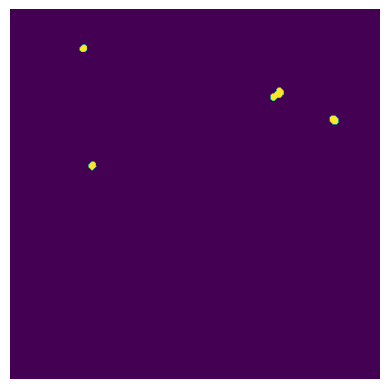

In [26]:
mn_pred = prob[0,:,:] > THRESHOLD
plt.imshow(mn_pred[1500:2000, 1500:2000])
plt.grid(False)
plt.axis('off')
plt.show()

- raw input

(2910, 2910)


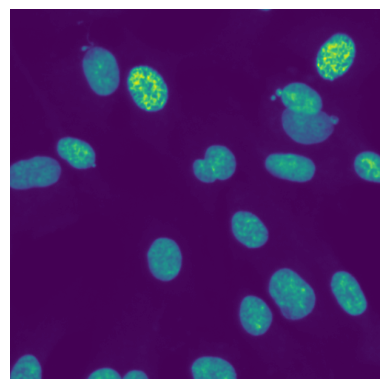

In [25]:
filename = '/scr/yren/scale_aligned_dataset_v2_v3/C1-20X_c0_phalloidin_C3_Tile-15.phenotype.tif'
im = skimage.io.imread(filename)
print(im.shape)
plt.imshow(im[1500:2000, 1500:2000])
plt.grid(False)
plt.axis('off')
plt.show()

- nuclei prediction

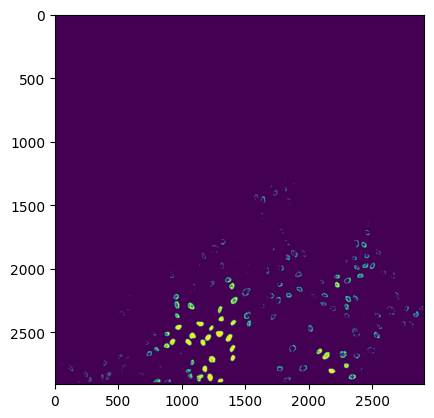

In [15]:
plt.imshow(prob[1,:,:] > THRESHOLD)

In [16]:
np.unique(prob[1,:,:])

array([0.        , 0.00390625, 0.00416667, ..., 0.99609375, 1.        ,
              nan], dtype=float32)

(2910, 2910, 4)


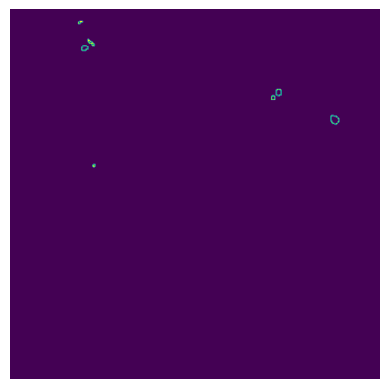

In [24]:
im = skimage.io.imread('/scr/yren/scale_aligned_dataset_v2_v3/C1-20X_c0_phalloidin_C3_Tile-15.phenotype_outlines.png')
print(im.shape)
plt.imshow(im[1500:2000,1500:2000,0])
plt.grid(False)
plt.axis('off')
plt.show()

In [21]:
mn_pred = prob[0,:,:] > THRESHOLD
mn_labels = skimage.measure.label(mn_pred)
print(np.unique(mn_labels))

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95
 96 97 98]


In [22]:
import matplotlib.pyplot as plt

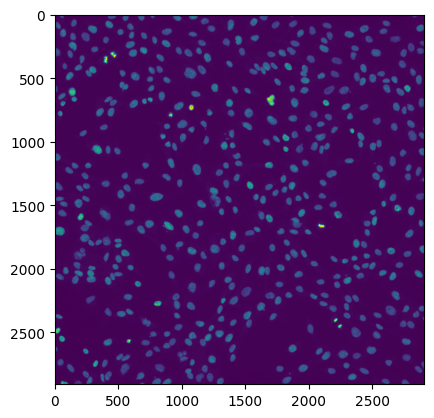

In [27]:
plt.imshow(im)

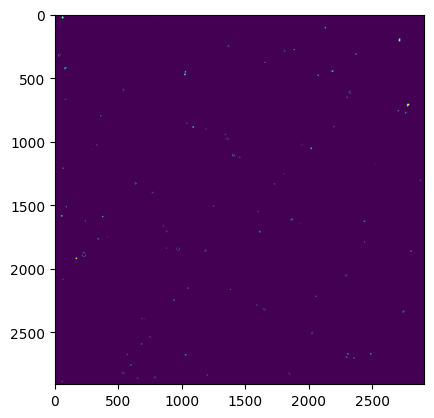

In [46]:
plt.imshow(mn_pred & ~mn_gt) # check the false positives, where True in predictions and True in background (originally False, so need NOT operation)

- Example 1

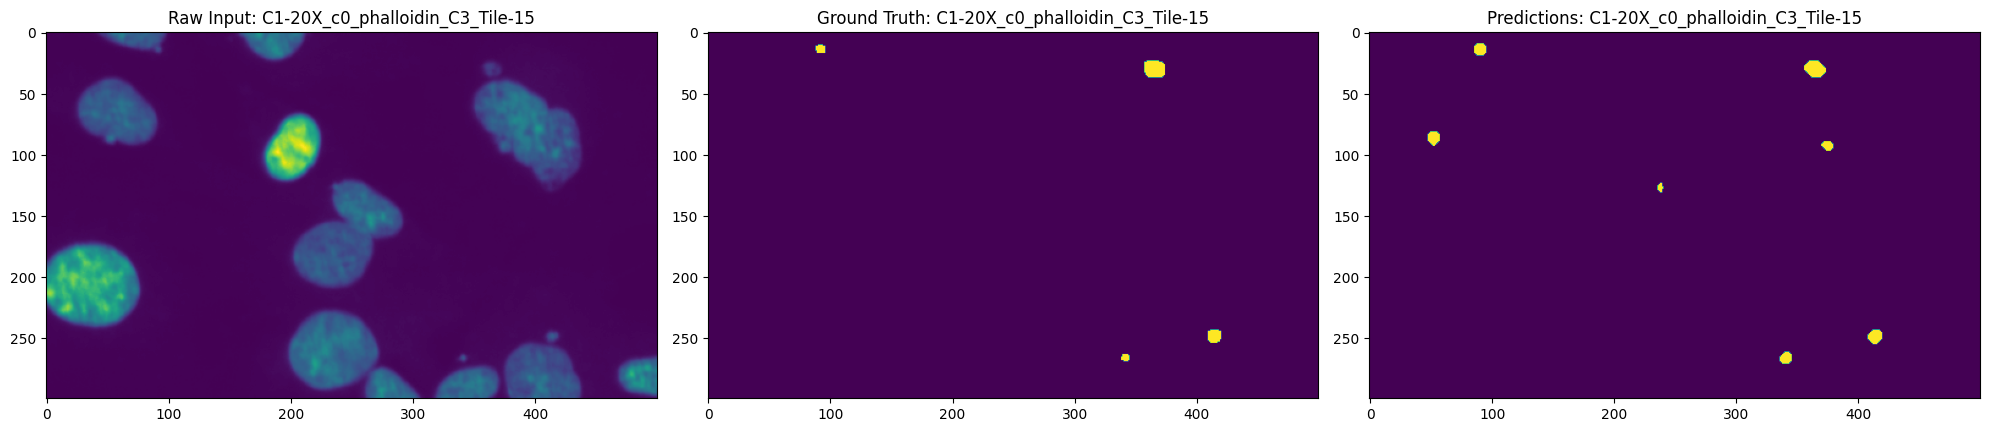

In [55]:
fig, ax = plt.subplots(1,3,figsize=(20,20))

row_start = 1500
row_end = 1800
column_start = 0
column_end = 500


ax[0].imshow(im[row_start:row_end, column_start:column_end])
ax[0].set_title(f'Raw Input: {imid}')

ax[1].imshow(mn_gt[row_start:row_end, column_start:column_end])
ax[1].set_title(f'Ground Truth: {imid}')

ax[2].imshow(mn_pred[row_start:row_end, column_start:column_end])
ax[2].set_title(f'Predictions: {imid}')

plt.tight_layout()
plt.show()

- Example 2

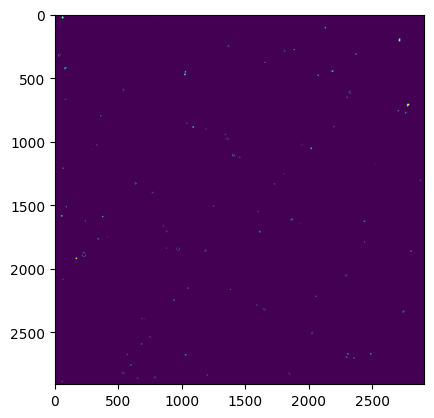

In [56]:
plt.imshow(mn_pred & ~mn_gt) # check the false positives, where True in predictions and True in background (originally False, so need NOT operation)

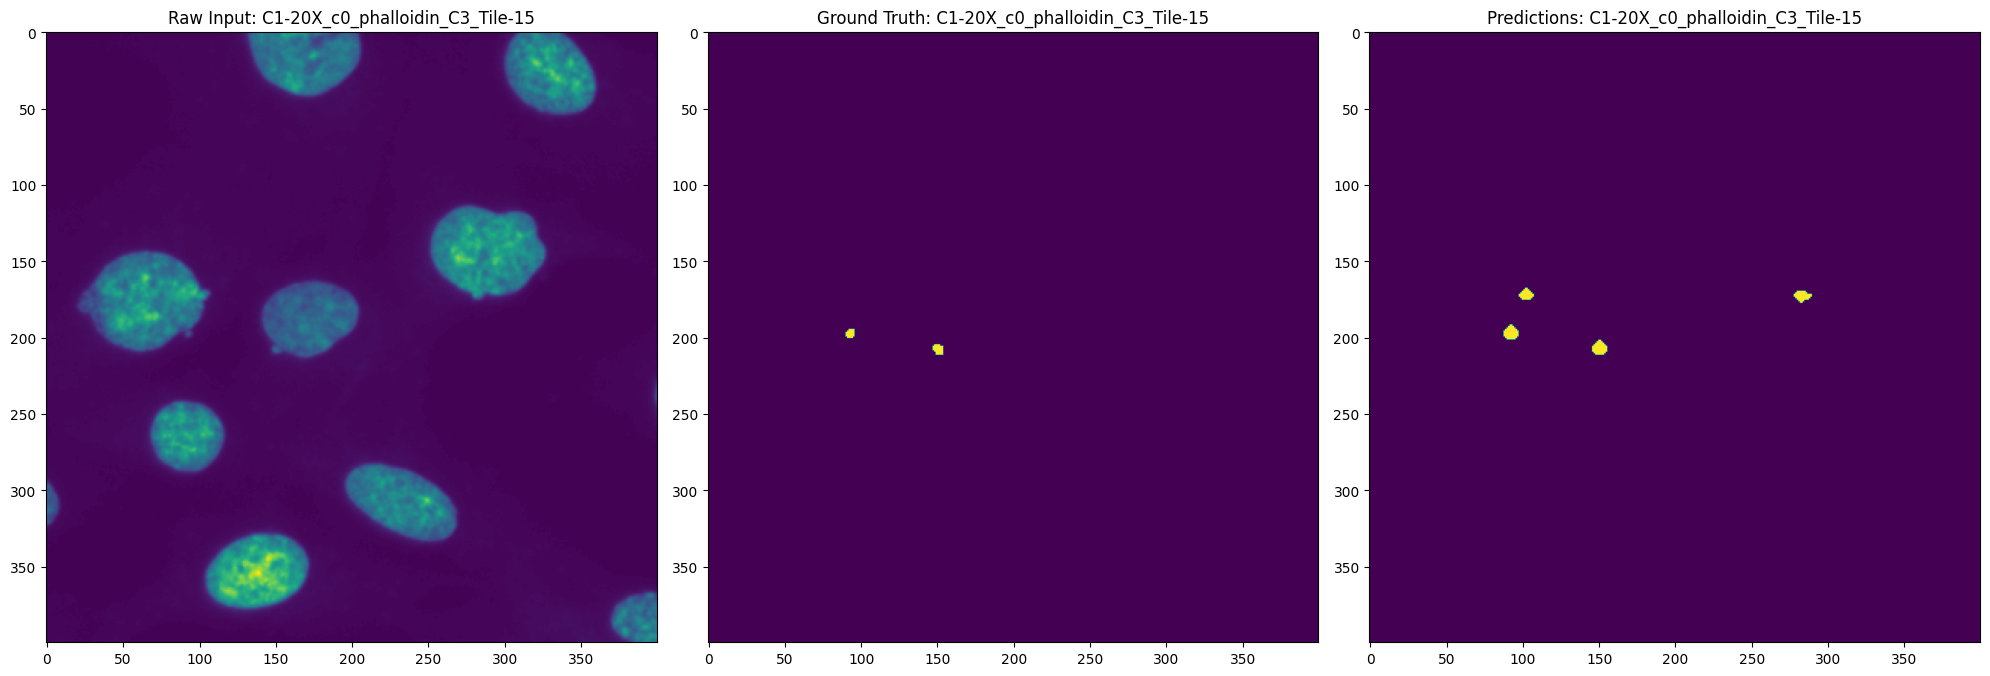

In [57]:
fig, ax = plt.subplots(1,3,figsize=(20,20))

row_start = 2500
row_end = 2900
column_start = 2200
column_end = 2600


ax[0].imshow(im[row_start:row_end, column_start:column_end])
ax[0].set_title(f'Raw Input: {imid}')

ax[1].imshow(mn_gt[row_start:row_end, column_start:column_end])
ax[1].set_title(f'Ground Truth: {imid}')

ax[2].imshow(mn_pred[row_start:row_end, column_start:column_end])
ax[2].set_title(f'Predictions: {imid}')

plt.tight_layout()
plt.show()

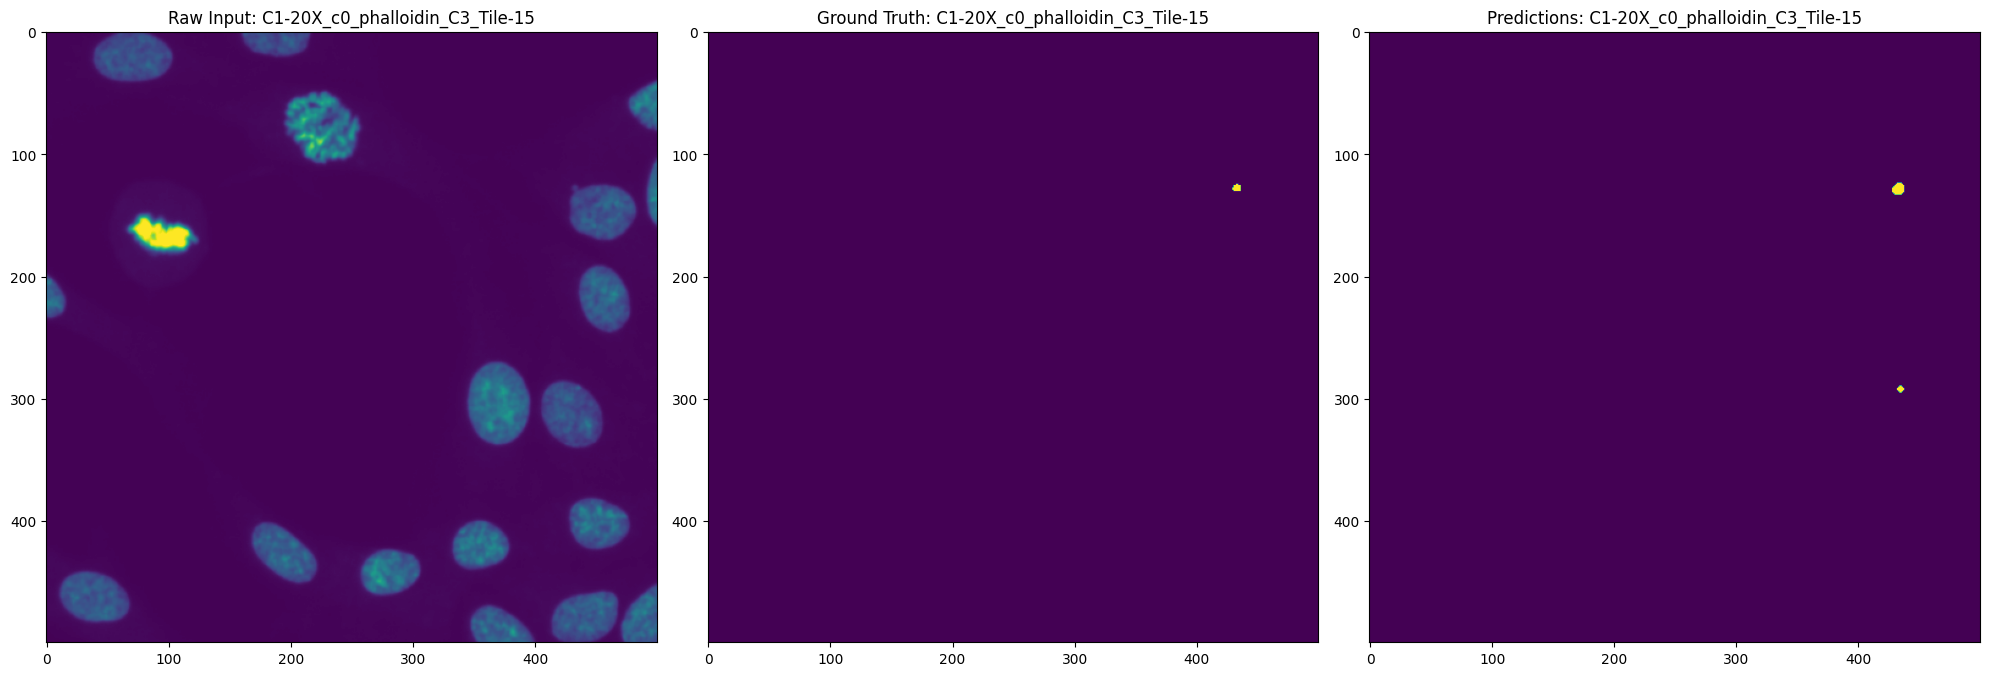

In [61]:
fig, ax = plt.subplots(1,3,figsize=(20,20))

row_start = 1500
row_end = 2000
column_start = 2000
column_end = 2500


ax[0].imshow(im[row_start:row_end, column_start:column_end])
ax[0].set_title(f'Raw Input: {imid}')

ax[1].imshow(mn_gt[row_start:row_end, column_start:column_end])
ax[1].set_title(f'Ground Truth: {imid}')

ax[2].imshow(mn_pred[row_start:row_end, column_start:column_end])
ax[2].set_title(f'Predictions: {imid}')

plt.tight_layout()
plt.show()

# Test learning rate scheduler

In [20]:
import sys
sys.path.append('../')
from microdet import detection
import torch
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
gpu = 3
device = f"cuda:{gpu}" if torch.cuda.is_available() else 'cpu'
model = detection.DetectionModel(device=device, finetune=True)

Using cache found in /home/MORGRIDGE/yren/.cache/torch/hub/facebookresearch_dinov2_main


In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-6)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer=optimizer,T_max=20, eta_min=1e-6)
lrs = []
for epoch in range(20):
    print(f"Epoch: {epoch}, lr {optimizer.param_groups[0]['lr']}")
    lrs.append(optimizer.param_groups[0]['lr'])
    scheduler.step()

Epoch: 0, lr 1e-05
Epoch: 1, lr 9.938441702975689e-06
Epoch: 2, lr 9.755282581475769e-06
Epoch: 3, lr 9.45503262094184e-06
Epoch: 4, lr 9.045084971874738e-06
Epoch: 5, lr 8.535533905932739e-06
Epoch: 6, lr 7.938926261462368e-06
Epoch: 7, lr 7.269952498697736e-06
Epoch: 8, lr 6.5450849718747394e-06
Epoch: 9, lr 5.7821723252011565e-06
Epoch: 10, lr 5.000000000000001e-06
Epoch: 11, lr 4.217827674798848e-06
Epoch: 12, lr 3.454915028125264e-06
Epoch: 13, lr 2.7300475013022666e-06
Epoch: 14, lr 2.061073738537635e-06
Epoch: 15, lr 1.4644660940672626e-06
Epoch: 16, lr 9.549150281252633e-07
Epoch: 17, lr 5.449673790581611e-07
Epoch: 18, lr 2.447174185242324e-07
Epoch: 19, lr 6.155829702431172e-08


/scr/yren/miniconda3/envs/micronuclei_detection/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:224: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


<Axes: >

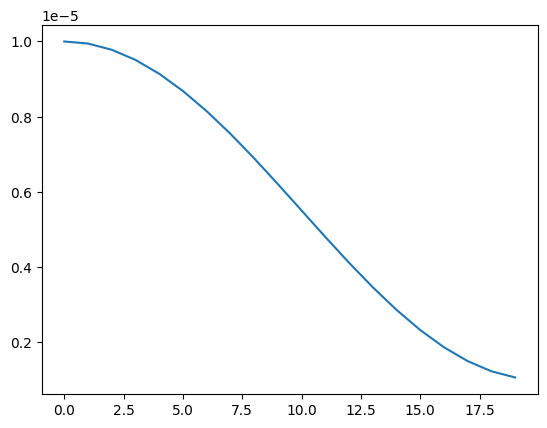

In [72]:
sns.lineplot(
    x=range(20),
    y=lrs
)

In [9]:
import os
files = os.listdir('/scr/yren/20241114_pilot_validation/20241114_pilot_validation_20X_c0_HeLa')
files = [file for file in files if not file.startswith('.')]
files = [file for file in files if file.endswith('.tif')]
print(len(files))

1596


In [2]:
import skimage
import numpy as np
import matplotlib.pyplot as plt

In [12]:
im = skimage.io.imread('/scr/yren/20241114_pilot_validation/20241114_pilot_validation_20X_c0_HeLa/' + files[0])
im = np.array((im - np.min(im))/(np.max(im) - np.min(im)), dtype="float32")
print(im.shape)

(2720, 2720, 3)


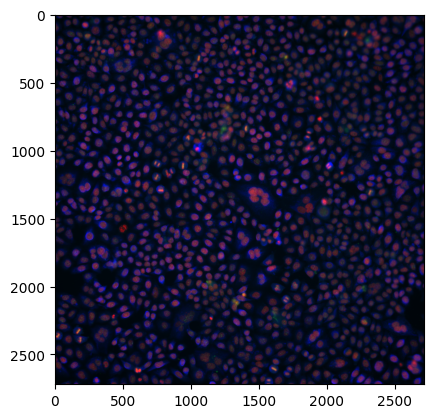

In [15]:
plt.imshow(im)

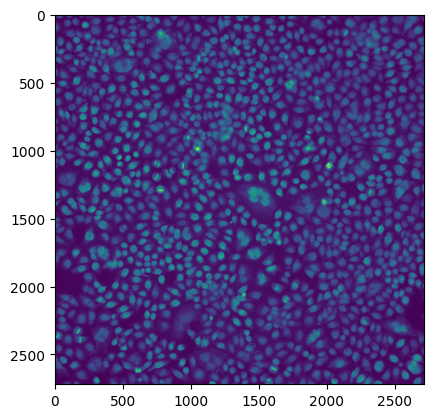

In [16]:
plt.imshow(np.mean(im, axis=2))

In [19]:
import torch
def patch_to_rgb(patch, edges=False):
    if edges:
        sobel = skimage.filters.sobel(patch)
        sobel = 2*skimage.exposure.rescale_intensity(sobel, out_range=np.float32)
        sobel[sobel > 1.] = 1.
    else:
        sobel = patch
        
    px = np.concatenate(
        (sobel[np.newaxis,:,:], patch[np.newaxis,:,:], patch[np.newaxis,:,:]), 
        axis=0)
    return torch.Tensor(px)

In [20]:
crop = patch_to_rgb(im, edges=True)

In [21]:
print(crop.shape)

torch.Size([3, 2720, 2720, 3])


In [23]:
im2 = skimage.io.imread('/scr/yren/20241114_pilot_validation/20241114_pilot_validation_20X_c0_RPE/20X_c0_C6_Tile-9.phenotype.tif')
print(im2.shape)

(2720, 2720, 3)


In [26]:
im3 = skimage.transform.rescale(im, 1.07)
print(im3.shape)

(2910, 2910, 3)


In [1]:
import os

In [2]:
os.listdir('/scr/yren/micronuclei-detection/microdet/20241114_pilot_validation_20X_c0_HeLa/model_output/output')

['best_model_v2_1.pth',
 '20X_c0_HeLa_B2_Tile-0._probabilities.npy',
 '20X_c0_HeLa_B2_Tile-1._probabilities.npy']

In [2]:
import numpy as np
prob = np.load('/scr/yren/micronuclei-detection/microdet/20241114_pilot_validation_20X_c0_HeLa/model_output/output/20X_c0_HeLa_B2_Tile-0._probabilities.npy')

FileNotFoundError: [Errno 2] No such file or directory: '/scr/yren/micronuclei-detection/microdet/20241114_pilot_validation_20X_c0_HeLa/model_output/output/20X_c0_HeLa_B2_Tile-0._probabilities.npy'

In [4]:
np.unique(prob)

array([0.        , 0.00390625, 0.00416667, ..., 0.99609375, 1.        ,
              nan], dtype=float32)

In [9]:
import matplotlib.pyplot as plt

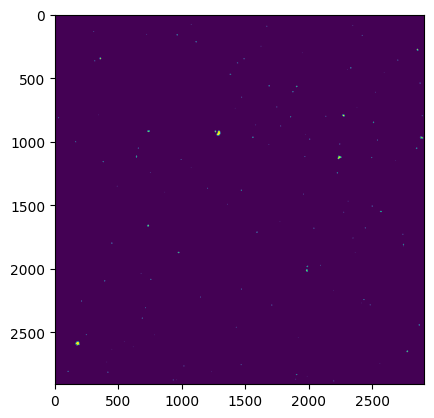

In [10]:
plt.imshow(prob)

In [3]:
import os
files = os.listdir('/scr/yren/micronuclei-detection/microdet/20241114_pilot_validation_20X_c0_RPE')
files = [file for file in files if not file.startswith('.')]
files = [file for file in files if file.endswith('.tif')]
print(len(files))

1596


In [4]:
files[0]

'20X_c0_C4_Tile-216.phenotype.tif'

In [16]:
im = skimage.io.imread('/scr/yren/micronuclei-detection/microdet/20241114_pilot_validation_20X_c0_RPE/20X_c0_C4_Tile-216.phenotype.tif')
print(im.shape)
print((len(im) > 2 and im.shape[2] == 3))

(2720, 2720, 3)
True


In [6]:
import matplotlib.pyplot as plt

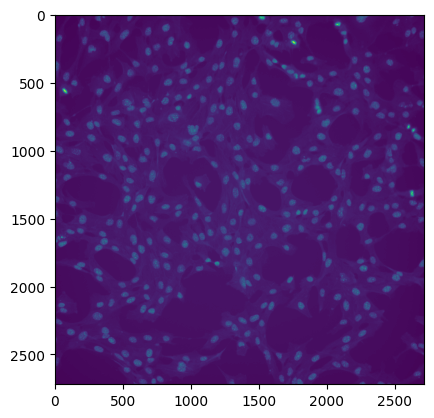

In [8]:
plt.imshow(np.mean(im, axis=2))

In [1]:
import numpy as np
p = np.load('/scr/yren/micronuclei-detection/microdet/20241114_pilot_validation_20X_c0_RPE/model_output/output/20X_c0_C1_Tile-107._probabilities.npy')
p = p > 0.5
print(np.unique(p))

[False  True]


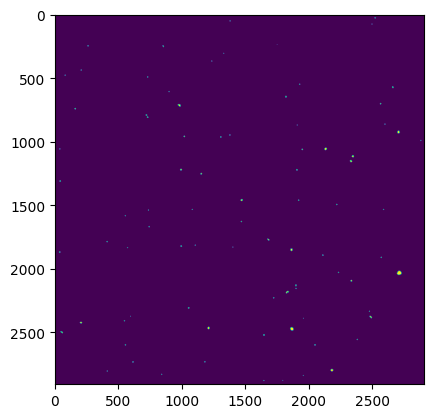

In [4]:
plt.imshow(p[0,:,:])

In [7]:
p2 = skimage.morphology.label(p[0,:,:]>0.5)
print(np.unique(p2))

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84]


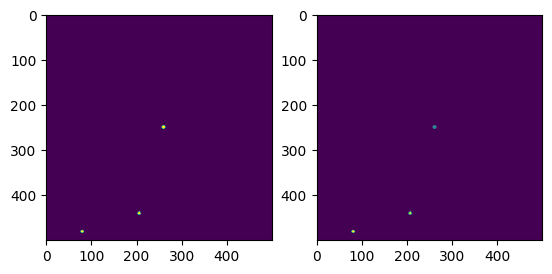

In [11]:
fig, ax = plt.subplots(1,2)
ax[0].imshow(p[0,0:500,0:500])
ax[1].imshow(p2[0:500,0:500])

In [1]:
import numpy as np
p = np.load('/scr/yren/micronuclei-detection/microdet/20241114_pilot_validation_20X_c0_RPE/model_output/RPE_labeled_output/20X_c0_C6_Tile-9._probabilities.npy')
print(np.unique(p))

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68]


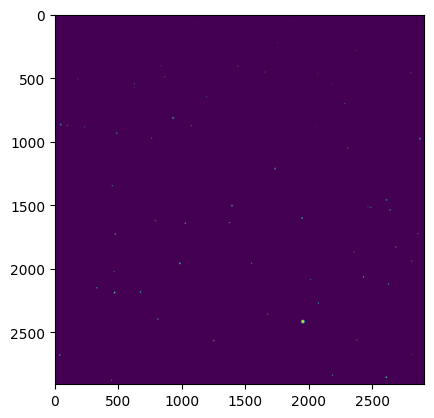

In [3]:
import matplotlib.pyplot as plt
plt.imshow(p)

In [ ]:
p2 = np.load('/scr/yren/HeLa/HeLa_output/20X_c0_HeLa_C4_Tile-9._probabilities.npy')

In [18]:
print(p2.shape)
np.unique(p2[0,:,:])[0:10]

(2, 2910, 2910)


array([0.        , 0.00390625, 0.00416667, 0.00446429, 0.00480769,
       0.00520833, 0.00568182, 0.00625   , 0.00694444, 0.00699301],
      dtype=float32)

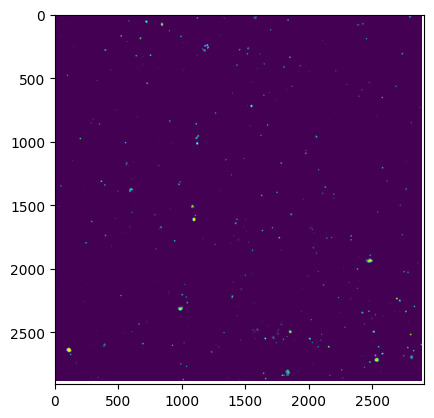

In [12]:
plt.imshow(p2[0,:,:])

In [14]:
import os
files = [file for file in os.listdir('/scr/yren/HeLa/HeLa_output/') if file.endswith('.npy')]
print(files[0:5])
print(len(files))

['20X_c0_HeLa_B2_Tile-0._probabilities.npy', '20X_c0_HeLa_B2_Tile-1._probabilities.npy', '20X_c0_HeLa_B2_Tile-10._probabilities.npy', '20X_c0_HeLa_B2_Tile-100._probabilities.npy', '20X_c0_HeLa_B2_Tile-101._probabilities.npy']
1596


In [1]:
p3 = np.load('/scr/yren/HeLa/HeLa_labeled_output/20X_c0_HeLa_C4_Tile-9._probabilities.npy')

NameError: name 'np' is not defined

In [19]:
print(p3.shape)
print(np.unique(p3))

(2910, 2910)
[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162]


In [6]:
import skimage
import matplotlib.pyplot as plt

In [4]:
im = skimage.io.imread('/scr/yren/dataset_v3_all/C1-20X_c0_phalloidin_C3_Tile-15.phenotype.tif')

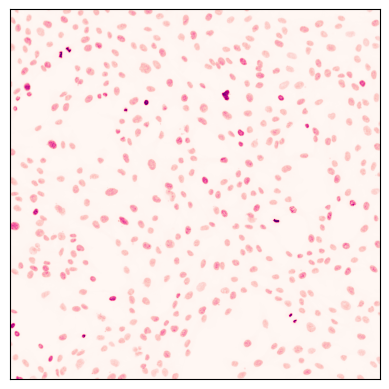

In [9]:
plt.imshow(im, cmap='RdPu')

plt.gca().get_xaxis().set_visible(False)
plt.gca().get_yaxis().set_visible(False)
plt.show()

# Debug randomize patch index function in new added data

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import skimage
import scipy

import torch
import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
path = '/scr/yren/micronuclei-detection/microdet/LOO_HeLa_RPE'
images = os.listdir(path)
images = [image for image in images if not image.startswith('.')]
images = [image for image in images if image.endswith('.phenotype.tif')]
print(len(images))

200


In [2]:
import sys
sys.path.append('../')
import microdet.mnds
from tqdm import tqdm

In [5]:
CURRENT_PATH = os.getcwd()
DIRECTORY = '/scr/yren/micronuclei-detection/microdet/LOO_HeLa_RPE'
files = os.listdir(DIRECTORY)
filelist = [file for file in files if not file.startswith('.')] # avoid files starting with . when untarring in CHTC
annot_files = [x for x in filelist if x.endswith('.phenotype_outlines.png')]
annot_files.sort()
training_files = annot_files.copy()
data_dir = DIRECTORY
del training_files[59]
validation_files = [annot_files[59]]

In [7]:
print(validation_files)
print(len(training_files))

['C1-20X_c0_B3_Tile-15.phenotype_outlines.png']
199


In [9]:
training_set = microdet.mnds.MicronucleiDataset(
    filelist=training_files,
    directory=data_dir, 
    mode="random",
    edges=True,
    transform=microdet.mnds.detection_transforms,
    scale_factor=1.0,
    patch_size=256,
    gaussian=True
)

100%|██████████| 199/199 [01:39<00:00,  2.00it/s]


ValueError: high <= 0

In [12]:
all_locs = []
images_dict = {}
for fname in tqdm(images):
    imid = fname.split('.')[0]
    im = microdet.mnds.read_image(path, imid, 'phenotype.tif', 1)
    im = np.array((im - np.min(im))/(np.max(im) - np.min(im)), dtype="float32")
    #im = skimage.exposure.rescale_intensity(im, out_range=np.float32)
    mni = microdet.mnds.read_micronuclei_annotations(path, imid)
    mnm = microdet.mnds.read_image(path, imid, 'phenotype_outlines.png', 1)
    nuc = microdet.mnds.read_nuclei_masks(path, imid)
    all_locs.append(mni)
    images_dict[imid] = {"image":im, "micro":mnm, "nuclei":nuc, "loc":mni}
    
all_locs = pd.concat(all_locs)

100%|██████████| 200/200 [01:42<00:00,  1.94it/s]


In [25]:
images_have_issues = []
for imid in images_dict:
    x = images_dict[imid]['loc']['x']
    print(len(x))
    if len(x) == 1:
        print(imid)
    if (len(x) > 1000):
        print(imid)
        images_have_issues.append(imid)

105
57
81
51
55
42
128
116
75
82
69
73
63
90
78
141
96
112
77
56
9
25
3
2
4
8
11
16
10
14
83
44
137
75
48
65
109
69
83
79
96
64
87
137
7
7
6
8
5
5
5
14
10
6
7
7
5
6
8
5
21
5
8
6
7
8
5
9
6
7
22
5
8
7
6
25
5
10
10
6
7
12
8
7
13
7
6
8
7
24
7
5
5
9
11
14
5
8
22
5
8
8
11
147
73
16
23
17
11
62
115
23
3
13
2
35
29
5
4
1
2023-05-31_misc-MCC13_rfpcyto_w1cDAPI_s47
187
52
60
83
5
19
5
6
9
7
7
10
7
5
5
8
5
8
15
17
9
5
5
9
5
6
11
10
6
6
9
12
8
7
5
14
7
9
5
10
113
63
4
163
142
78
83
100
9
9
5
10
16
8
8
6
7
14
6
14
9
5
4
7
24
9
6
10
7
5
15
5
10
11
11
13
7
9
7
5


In [18]:
images_have_issues

[]

In [24]:
for i in range(len(annot_files)):
    im = skimage.io.imread(f'/scr/yren/micronuclei-detection/microdet/LOO_HeLa_RPE/{annot_files[i]}')
    print(im.shape)

(1382, 1564)
(1382, 1564)
(1382, 1564)
(1382, 1564)
(1382, 1564)
(1382, 1564)
(1382, 1564)
(1382, 1564)
(1382, 1564)
(1382, 1564)
(1382, 1564)
(1382, 1564)
(1382, 1564)
(1382, 1564)
(1382, 1564)
(1382, 1564)
(1382, 1564)
(1382, 1564)
(1382, 1564)
(1382, 1564)
(1382, 1564)
(1382, 1564)
(1382, 1564)
(1382, 1564)
(922, 922)
(1843, 1843)
(1843, 1843)
(922, 922)
(922, 922)
(922, 922)
(1843, 1843)
(1843, 1843)
(1843, 1843)
(1843, 1843)
(1843, 1843)
(922, 922)
(922, 922)
(922, 922)
(922, 922)
(1843, 1843)
(922, 922)
(563, 563)
(563, 563)
(563, 563)
(922, 922)
(922, 922)
(922, 922)
(922, 922)
(922, 922)
(2960, 2960)
(2960, 2960)
(2960, 2960)
(2960, 2960)
(2960, 2960)
(2960, 2960)
(2960, 2960)
(2960, 2960)
(2960, 2960)
(2960, 2960)
(2992, 2992)
(2992, 2992)
(2992, 2992)
(2992, 2992)
(2992, 2992)
(2992, 2992)
(2960, 2960)
(2960, 2960)
(2960, 2960)
(2960, 2960)
(2960, 2960)
(2960, 2960)
(2960, 2960)
(2960, 2960)
(1144, 1531)
(1144, 1531)
(1144, 1531)
(1144, 1531)
(1144, 1531)
(1144, 1531)
(1144, 

# NICE! No images have issue now!

In [4]:
path = '/scr/yren/all_data_micronuclei/mnfinder_clean_data/training/'
mask = skimage.io.imread(path + '2022-05-27_RPE1-1.phenotype_outlines.png')
print(mask.shape)

(768, 869, 4)


In [5]:
mask = np.mean(mask, axis=2)
print(mask.shape)

(768, 869)


In [6]:
labels = skimage.morphology.label(mask)
print(np.unique(labels))

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79]


In [7]:
metadata = pd.read_csv('/scr/yren/all_data_micronuclei/metadata.csv')
metadata[metadata['filenames'] == '2022-05-27_RPE1-1.phenotype.tif']

,filenames,datasets,magnification,micron,split
1,2022-05-27_RPE1-1.phenotype.tif,mnfinder_train,20,11.0,train


In [8]:
(14/4.25)/(20/11)

1.811764705882353

In [9]:
mask_scaled = skimage.transform.rescale(mask, 1.8, order=0) # nearest neightbor
print(mask.shape)
print(mask_scaled.shape)
new_labels = skimage.morphology.label(mask_scaled > 0)
print(np.unique(new_labels))

(768, 869)
(1382, 1564)
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73]


In [11]:
mask2 = mask > 0
np.unique(mask2)

array([False,  True])

In [127]:
areas_no_scale = []
for i in range(1, len(np.unique(mask))):
    area = np.sum(labels==i)
    areas_no_scale.append(int(area))
    
areas_scaled = []
for i in range(1, len(np.unique(mask_scaled))):
    area = np.sum(new_labels==i)
    areas_scaled.append(int(area))

In [128]:
print(areas_no_scale)

[50, 20, 6, 38, 24, 12, 52, 34, 90, 14, 4, 22, 11, 56, 33, 24, 65, 21, 22, 16, 47, 19, 28, 32, 18, 15, 5, 25, 26, 7, 10, 12, 8, 19, 20, 9, 19, 11, 20, 20, 27, 10, 16, 26, 20, 8, 22, 6, 26, 9, 10, 20, 18, 10]


In [129]:
print(areas_scaled)

[159, 64, 24, 122, 72, 44, 161, 113, 288, 48, 12, 69, 38, 182, 107, 81, 214, 65, 71, 47, 153, 61, 95, 102, 55, 47, 20, 85, 87, 26, 38, 37, 30, 63, 72, 32, 64, 38, 70, 65, 85, 29, 56, 82, 67, 21, 78, 20, 82, 30, 29, 63, 59, 34]


In [132]:
mask_scaled2 = skimage.transform.rescale(mask, 1.8, order=1) # bilinear interpolation
np.unique(mask_scaled2)

array([0.00000000e+00, 2.48733719e-03, 4.38675832e-03, ...,
       1.96500000e+02, 1.96500000e+02, 1.96750000e+02])

In [134]:
print(np.unique(mask))

[  0.   154.5  163.75 167.75 170.5  174.75 175.   175.75 176.   176.25
 176.5  176.75 177.   177.25 177.75 178.   178.5  178.75 179.   179.75
 180.25 181.5  182.   183.5  183.75 184.   184.25 185.   185.25 185.5
 185.75 186.25 186.5  187.75 188.   189.   189.25 190.   191.   191.25
 191.75 192.   192.25 193.25 193.5  193.75 194.25 194.5  194.75 195.
 195.25 195.5  195.75 196.5  196.75]


In [133]:
np.unique(mask_scaled)

array([  0.  , 154.5 , 163.75, 167.75, 170.5 , 174.75, 175.  , 175.75,
       176.  , 176.25, 176.5 , 176.75, 177.  , 177.25, 177.75, 178.  ,
       178.5 , 178.75, 179.  , 179.75, 180.25, 181.5 , 182.  , 183.5 ,
       183.75, 184.  , 184.25, 185.  , 185.25, 185.5 , 185.75, 186.25,
       186.5 , 187.75, 188.  , 189.  , 189.25, 190.  , 191.  , 191.25,
       191.75, 192.  , 192.25, 193.25, 193.5 , 193.75, 194.25, 194.5 ,
       194.75, 195.  , 195.25, 195.5 , 195.75, 196.5 , 196.75])

# Debug Prediction

In [1]:
import sys
import os
import sys
import time
import skimage.morphology
import torch
import skimage
import sklearn.metrics
import wandb
from tqdm import tqdm

import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

In [2]:
class DetectionModel(torch.nn.Module):
    
    def __init__(self, device, stride=8, finetune=False):
        super(DetectionModel, self).__init__()
        
        self.finetune = finetune
        
        # pretrained backbone has patch size 14 x 14, split into 14 row and columns
        self.feature_extractor = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14_reg').to(device) # dinov2 vit small model
        
        self.upscale1 = torch.nn.ConvTranspose2d(in_channels=384, out_channels=192, kernel_size=(2,2), stride=2)
        self.upscale1.to(device)
        self.block1 = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels=192, out_channels=192, kernel_size=(3,3), padding=(1,1)),
            torch.nn.LayerNorm([192, 64, 64]), # nn.LayerNorm([C, H, W])
            torch.nn.ReLU(),
        )
        self.block2 = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels=192, out_channels=192, kernel_size=(3,3), padding=(1,1)),
            torch.nn.LayerNorm([192, 64, 64]), # nn.LayerNorm([C, H, W])
            torch.nn.ReLU(),
        )
        self.block3 = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels=192, out_channels=192, kernel_size=(3,3), padding=(1,1)),
            torch.nn.LayerNorm([192, 64, 64]), # nn.LayerNorm([C, H, W])
            torch.nn.ReLU(),
        )
        self.block1.to(device)
        self.block2.to(device)
        self.block3.to(device)
        
        self.upscale2 = torch.nn.ConvTranspose2d(in_channels=192, out_channels=96, kernel_size=(2,2), stride=2)
        self.upscale2.to(device)
        self.block4 = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels=96, out_channels=96, kernel_size=(3,3), padding=(1,1)),
            torch.nn.LayerNorm([96, 128, 128]), # best
            torch.nn.ReLU(),
        )
        self.block5 = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels=96, out_channels=96, kernel_size=(3,3), padding=(1,1)),
            torch.nn.LayerNorm([96, 128, 128]), # best
            torch.nn.ReLU(),
        )
        self.block6 = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels=96, out_channels=96, kernel_size=(3,3), padding=(1,1)),
            torch.nn.LayerNorm([96, 128, 128]), # best
            torch.nn.ReLU(),
        )
        self.block4.to(device)
        self.block5.to(device)
        self.block6.to(device)
        
        # classification layer
        self.classifier = torch.nn.Conv2d(in_channels=96, out_channels=2, kernel_size=(1,1))
        self.classifier.to(device)
                
    def forward(self, x):
        # Skip Connections
        if self.finetune:
            x = torch.nn.functional.interpolate(x, (448,448))
            x = self.feature_extractor.forward_features(x)['x_norm_patchtokens']
            B,T,C = x.shape # Batch, Token size * Toekn size, Channel
            W,H = 32,32
            x = x.reshape(B,W,H,C).permute(0,3,1,2)
            # x = self.decoder(x)
            
            x = self.upscale1(x)
            residual1 = x
            x = self.block1(x)
            residual2 = x
            x = self.block2(x) + residual1
            x = self.block3(x) + residual2
            
            x = self.upscale2(x)
            residual3 = x
            x = self.block4(x)
            residual4 = x
            x = self.block5(x) + residual3
            x = self.block6(x) + residual4
            
            x = self.classifier(x)
        else:
            with torch.no_grad():
                x = torch.nn.functional.interpolate(x, (448,448))
                x = self.feature_extractor.forward_features(x)['x_norm_patchtokens']
            B,T,C = x.shape # Batch, Token size * Toekn size, Channel
            W,H = 32,32
            x = x.reshape(B,W,H,C).permute(0,3,1,2)
            # x = self.decoder(x)
            
            x = self.upscale1(x)
            residual1 = x
            x = self.block1(x)
            residual2 = x
            x = self.block2(x) + residual1
            x = self.block3(x) + residual2
            
            x = self.upscale2(x)
            residual3 = x
            x = self.block4(x)
            residual4 = x
            x = self.block5(x) + residual3
            x = self.block6(x) + residual4
            
            x = self.classifier(x)
        
        return x


In [3]:
class DiceLoss(torch.nn.Module):
    def __init__(self, alpha=0.8, beta=0.2, smoothing=1e-5, reduction='mean'):
        """_summary_

        Args:
            alpha (_type_): weight for micronuclei class, default=0.8
            beta (_type_): weight for nuclei class, default=0.2
            smoothing (_type_, optional): smoothing parameter for numerical stability. Defaults to 1e-5.
            reduction (str, optional): Reduction method. Defaults to 'mean'.
        """
        super(DiceLoss, self).__init__()
        self.alpha = alpha
        self.beta = beta
        self.smoothing = smoothing
        self.reduction = reduction

    def forward(self, prediction, ground_truth):
        # Conclusion, do not use one-hot encoding
        
        assert prediction.shape == ground_truth.shape, f'Predictions shape does not match the ground truth!'
        
        probs = torch.sigmoid(prediction)
        ground_truth = ground_truth.long()
        
        num = probs * ground_truth # numerator
        num = torch.sum(num, dim=(2,3))  # Sum over all pixels NxCxHxW --> NxC
        
        den1 = probs * probs # 1st denominator
        den1 = torch.sum(den1, dim=(2,3))
        
        den2 = ground_truth * ground_truth # 2nd denominator
        den2 = torch.sum(den2, dim=(2,3))
        
        # dice_loss = 2. * (num+ self.smoothing) / (den1 + den2 + self.smoothing)
        dice_loss_mn = 2. * (num[:,0]+ self.smoothing) / (den1[:,0] + den2[:,0] + self.smoothing)
        dice_loss_n = 2. * (num[:,1]+ self.smoothing) / (den1[:,1] + den2[:,1] + self.smoothing)
        
        if self.reduction == 'mean':
            dice_loss = 1 - (self.alpha * torch.mean(dice_loss_mn) + self.beta * torch.mean(dice_loss_n))
            # dice_loss = 1 - torch.mean(dice_loss)
        elif self.reduction == 'sum':
            dice_loss = 1 - (self.alpha * torch.sum(dice_loss_mn) + self.beta * torch.sum(dice_loss_n))
            # dice_loss = 1 - torch.sum(dice_loss)
        else:
            raise ValueError("'Reduction method must be either 'mean' or 'sum'")
        
        return dice_loss
    
class FocalLoss(torch.nn.Module):
    """_summary_
    Code are copied from torchvision.ops.sigmoid_focal_loss function
    """
    def __init__(self, alpha=0.25, gamma=2.0, reduction: str="mean"):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction="none")
        p = torch.sigmoid(inputs)
        p_t = p * targets + (1 - p) * (1 - targets)
        loss = ce_loss * ((1 - p_t) ** self.gamma)

        if self.alpha >= 0:
            alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
            loss = alpha_t * loss
            
        if self.reduction == "mean":
            loss = loss.mean()
        elif self.reduction == "sum":
            loss = loss.sum()
        else:
            raise ValueError(
                f"Invalid Value for arg 'reduction': '{self.reduction} \n Supported reduction modes: 'mean', 'sum'"
            )
        return loss
    
class CombinedFocalDiceLoss(torch.nn.Module):
    def __init__(self, focal_weight=0.95, dice_weight=0.05, alpha=0.25, gamma=2.0, reduction='mean', dice_alpha=0.8, dice_beta=0.2, smoothing=1e-5):
        super().__init__() # call initialization method from torch.nn.Module
        self.focal_loss = FocalLoss(alpha=alpha, gamma=gamma, reduction=reduction)
        self.dice_loss = DiceLoss(alpha=dice_alpha, beta=dice_beta, smoothing=smoothing, reduction=reduction)
        self.focal_weight = focal_weight
        self.dice_weight = dice_weight

    def forward(self, inputs, targets):
        loss_focal = self.focal_loss(inputs, targets)
        loss_dice = self.dice_loss(inputs, targets)
        combined_loss = self.focal_weight * loss_focal + self.dice_weight * loss_dice
        return combined_loss
        
class MicronucleiModel():
    
    def __init__(self, data_dir, device, training_files=[], validation_files=[], edges=False, patch_size=256, scale_factor=1.0, gaussian=False):
        self.data_dir = data_dir
        self.device = device
        self.validation_files = validation_files
        self.patch_size = patch_size
        self.gaussian = gaussian
        
        if len(training_files) > 0:
            self.training_set = mnds.MicronucleiDataset(
                filelist=training_files, 
                directory=data_dir, 
                mode="random",
                edges=edges,
                transform=mnds.detection_transforms,
                scale_factor=scale_factor,
                patch_size=patch_size,
                gaussian=gaussian
            )
        
        if len(validation_files) > 0:
            self.validation_set = mnds.MicronucleiDataset(
                filelist=validation_files, 
                directory=data_dir, 
                mode="fixed",
                edges=edges,
                scale_factor=scale_factor,
                patch_size=patch_size,
                gaussian=gaussian
            )
            self.need_validation_set = True
        else:
            self.need_validation_set = False
        
    def start_model(self, batch_size, learning_rate, loss_fn, finetune=False, weight_decay=1e-6):
        # batch_size means number of images for each batch
        self.train_dataloader = DataLoader(self.training_set, batch_size=batch_size, shuffle=True)
        
        if self.need_validation_set: # case for train the best model with all 18 images
            self.val_dataloader = DataLoader(self.validation_set, batch_size=4, shuffle=False)
        
        self.model = DetectionModel(device=self.device, finetune=finetune)
    
        # self.loss_fn = torch.nn.BCEWithLogitsLoss()
        if loss_fn == 'dice':
            self.loss_fn = DiceLoss(alpha=0.8, beta=0.2, smoothing=1e-5, reduction='mean')
        elif loss_fn == 'focal':
            self.loss_fn = FocalLoss(alpha=0.25, gamma=1, reduction='mean')
        elif loss_fn == 'combined':
            # Use all default parameters, gamma = 2 so far is good
            self.loss_fn = CombinedFocalDiceLoss(focal_weight=0.95, dice_weight=0.05, alpha=0.25, gamma=2, reduction='mean', dice_alpha=0.8, dice_beta=0.2, smoothing=1e-5)
            
        self.optimizer = torch.optim.AdamW(self.model.parameters(), lr=learning_rate, weight_decay=weight_decay) #, momentum=0.9) # add weight decy / regularization
        
        self.scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer=self.optimizer,
            T_max=20, # max number of training epochs,
            eta_min=learning_rate * 0.1
        )
        
        
    def train_one_epoch(self):
        running_loss = 0.
        last_loss = 0.

        self.train_dataloader.dataset.randomize_patch_index()
        for i, data in enumerate(self.train_dataloader):
            x, y = data
            
            self.optimizer.zero_grad()
            p = self.model(x.to(self.device))

            # output resolution: 128
            p = torch.nn.functional.interpolate(p, (self.patch_size, self.patch_size))
            
            # Loss function   
            Y = y.to(self.device).float()
            # Y = Y.unsqueeze(dim=1)
            
            # decoder_params = torch.cat([x.view(-1) for x in self.model.decoder.parameters()])
            # l2_regularization = l2_penalty * torch.norm(decoder_params, 2)
            loss = self.loss_fn(p, Y)
            
            # Training instructions
            loss.backward()
            
            # Update weights
            self.optimizer.step()
            
            # Report results
            running_loss += loss.item()
        return running_loss / i
    
    
    def train(self, epochs, batch_size, learning_rate, loss_fn, finetune=False, weight_decay=1e-6):
        self.start_model(batch_size=batch_size, learning_rate=learning_rate, loss_fn=loss_fn, finetune=finetune, weight_decay=weight_decay)
        
        best_vloss = 1_000_000.

        start = time.time()
        for epoch in range(epochs):
            # Training
            # print(f'EPOCH {epoch} - ', end='') # comment only for grid search purpose
            T = time.time()
            self.model.train(True)
            avg_loss = self.train_one_epoch()
            
            # Update learning rate per epoch
            wandb.log({'current_lr':self.optimizer.param_groups[0]['lr']})
            self.scheduler.step()
            

            # Validation
            if self.need_validation_set:
                running_vloss = 0.0
                self.model.eval()
                with torch.no_grad():
                    for i, vdata in enumerate(self.val_dataloader):
                        vin, vls = vdata
                        vout = self.model(vin.to(self.device))
                        # output resolution: 128
                        vout = torch.nn.functional.interpolate(vout, (self.patch_size, self.patch_size))
                        Y = vls.to(self.device).float()
                        
                        vloss = self.loss_fn(vout, Y)
                        running_vloss += vloss
                avg_vloss = running_vloss / (i+1)
            C = time.time() - T
            # print(f'LOSS: Training: {avg_loss} - Validation: {avg_vloss} - Time: {C:.2f} secs') # comment only for grid search purpose

            # log metrics to wandb
            if self.need_validation_set:
                wandb.log({"Train_loss":avg_loss, "Validation_loss":avg_vloss})
            else:
                wandb.log({"Train_loss":avg_loss})

        C = time.time() - start
        # print(f"\nTrainined finished in {C:.2f} seconds") # comment out for grid search
        wandb.log({"Train time":C})

        
    def save(self, outdir="models/"):
        # if self.need_validation_set: # LOO
        #     output_file = self.data_dir + outdir + self.validation_files[0].replace('phenotype_outlines.png','pth')
        # # elif self.gaussian:
        # #     output_file = f'{self.data_dir}{outdir}best_model_gaussian.pth'
        # else: # train with all images
        output_file = f'{self.data_dir}{outdir}best_model_v3.pth'
        torch.save(self.model.state_dict(), output_file)

        
    def load(self, model_name, model_dir="models/"):
        model_file = self.data_dir + model_dir + model_name
        self.model = DetectionModel(device=self.device)
        self.model.load_state_dict(torch.load(model_file))
        self.model.to(self.device)
        
        
    def predict(self, image, stride=1, step=16, batch_size=512, dilation=0):
        classes = self.model.classifier.out_channels
        probabilities = np.zeros((classes, image.shape[0]//stride, image.shape[1]//stride), dtype=np.float32)
        counts = np.zeros((image.shape[0]//stride, image.shape[1]//stride), dtype=np.float32)
        TOKENS_PER_PATCH = self.patch_size // stride # 256, same as self.patch_size
        ones = np.ones((TOKENS_PER_PATCH, TOKENS_PER_PATCH))
        batch, coords = [], []

        self.model.eval()

        def batch_predict(batch, coords):
            B = torch.cat(batch, axis=0)
            # pred0 = F.softmax(self.model(B.to(self.device))) need to be changed
            output = self.model(B.to(self.device))
            
            output = torch.nn.functional.interpolate(output, (self.patch_size,self.patch_size))
            
            # the output is not probability here (weights instead), last layer of detection model is binary classification, so we transform output to binary values.
            # classify pixel-wisely to 0 or 1, and scan all over the input image, and then average them, it is probability at the end.
            output = output > 0.0
            
            pred0 = output.float()
            P = torch.reshape(pred0, (-1, classes, TOKENS_PER_PATCH, TOKENS_PER_PATCH))
            P = P.cpu().numpy()
            # print(f'P shape in batch_predict(): {P.shape}')
            
            # Postprocessing - only dilate the micronuclei channel
            if dilation != 0:
                dilated_P = np.zeros_like(P)
                for i in range(0, dilated_P.shape[0]): # iterate all batches
                    dilated_P[i,0,:,:] = skimage.morphology.dilation(P[i,0,:,:], footprint=skimage.morphology.disk(dilation))
                P[:,0,:,:] = dilated_P[:,0,:,:] # replace micronuclei channel with dilated one
            
            for c in range(len(coords)):
                y = coords[c]["a"]
                x = coords[c]["b"]
                probabilities[:,y:y+TOKENS_PER_PATCH,x:x+TOKENS_PER_PATCH] += P[c]
                counts[y:y+TOKENS_PER_PATCH,x:x+TOKENS_PER_PATCH] += ones
            coords = []


        with torch.no_grad():
            for i in tqdm(range(0,image.shape[0]-self.patch_size+1, step)):
                a = i // stride
                for j in range(0,image.shape[1]-self.patch_size+1, step):
                    b = j // stride
                    vin = mnds.patch_to_rgb(image[i:i+self.patch_size,j:j+self.patch_size])
                    batch.append(vin[None,:,:,:])
                    coords.append({"i":i, "j":j, "a":a, "b":b})

                    if len(batch) == batch_size:
                        # Get predictions
                        batch_predict(batch, coords)
                        batch, coords = [], []

            if len(batch) > 0:
                batch_predict(batch, coords)
                batch, coords = [], []

        probabilities = probabilities/counts
        return probabilities
    


In [ ]:
PATCH_SIZE = 256
OUTPUT_DIR = "/model_output/output/"
models_dir = OUTPUT_DIR

model = MicronucleiModel(
    '/scr/yren/micronuclei-detection/microdet/all_data_micronuclei/train',
    'cuda:3', 
    patch_size=PATCH_SIZE, 
    edges=True, 
    gaussian=False # not needed in predict() function
)

model.load('best_model_v3.pth', model_dir=models_dir)
# model.load('best_model_v2_1.pth', model_dir=models_dir)


Using cache found in /home/MORGRIDGE/yren/.cache/torch/hub/facebookresearch_dinov2_main
/tmp/ipykernel_312181/188689726.py:248: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
 

In [5]:
DIRECTORY = '/scr/yren/micronuclei-detection/microdet/all_data_micronuclei/validation'
files = os.listdir(DIRECTORY)
filelist = [file for file in files if not file.startswith('.')]
annot_files = [x for x in filelist if x.endswith('.phenotype_outlines.png')]
annot_files.sort()
annot_files

['2022-05-26_RPE1-2198.phenotype_outlines.png',
 '2022-10-14_U2OS-1.phenotype_outlines.png',
 '2023-05-31_misc-4.phenotype_outlines.png',
 '20X_c0-DAPI_A1_Tile-50.phenotype_outlines.png',
 'C1-20X_c0_B3_Tile-24.phenotype_outlines.png',
 'C1-20X_c0_phalloidin_C3_Tile-15.phenotype_outlines.png',
 'C2-20X_c0-DAPI-GFP_A2_Tile-5.phenotype_outlines.png',
 'C2-20X_c0-DAPI-GFP_B3_Tile-16.phenotype_outlines.png',
 'IXMtest_B04_s4_w1F6AEFA0F-AF87-4B3B-A334-698647CFE043.phenotype_outlines.png',
 'IXMtest_B12_s2_w19F7E0279-D087-4B5E-9899-61971C29CB78.phenotype_outlines.png',
 'IXMtest_B19_s7_w1E43B84DB-39E2-4BFB-8CB4-554B32098C75.phenotype_outlines.png',
 'IXMtest_C18_s1_w11C16FC59-2E29-496A-803A-89581FDF538A.phenotype_outlines.png',
 'IXMtest_D02_s8_w1AC6783DF-ED35-4818-8091-E6D02AF4BFBD.phenotype_outlines.png',
 'IXMtest_D07_s4_w16CF58D03-0B05-41FE-AE73-7298887DEBB1.phenotype_outlines.png',
 'IXMtest_D19_s6_w1EB1F11AE-4FB6-481F-94D9-40246870F0CB.phenotype_outlines.png',
 'IXMtest_E06_s3_w1701573

In [7]:
import sys
sys.path.append('../')
import microdet.mnds as mnds

In [22]:
imid = 'C1-20X_c0_B3_Tile-24'
im = mnds.read_image(DIRECTORY, imid, 'phenotype.tif', scale=1)
im = np.array((im - np.min(im))/(np.max(im) - np.min(im)), dtype="float32")
mn_gt = mnds.read_image(DIRECTORY, imid, 'phenotype_outlines.png', scale=1)
# mn_gt = mn_gt > 0 # convert to boolean (binary mask)

In [25]:
probabilities = model.predict(im, stride=1, step=16, batch_size=32, dilation=2)

100%|██████████| 172/172 [04:38<00:00,  1.62s/it]


C1-20X_c0_B3_Tile-24


Text(0.5, 1.0, 'Ground truth micronuclei mask')

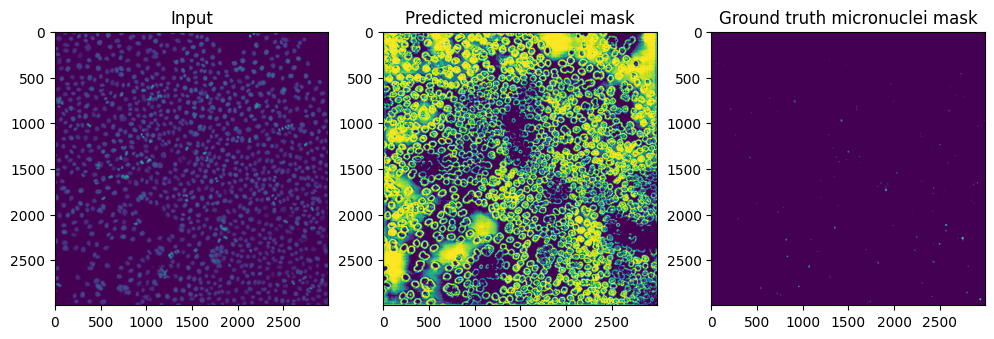

In [30]:
fig, ax = plt.subplots(1,3,figsize=(12,12))

print(imid)
ax[0].imshow(im)
ax[0].set_title('Input')

mn_pred = probabilities[0,:,:] > 0.5
ax[1].imshow(mn_pred)
ax[1].set_title('Predicted micronuclei mask')

ax[2].imshow(mn_gt)
ax[2].set_title('Ground truth micronuclei mask')

In [31]:
np.unique(mn_gt)

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142],
      dtype=uint16)

In [32]:
imid = '20X_c0-DAPI_A1_Tile-50'
im = mnds.read_image(DIRECTORY, imid, 'phenotype.tif', scale=1)
im = np.array((im - np.min(im))/(np.max(im) - np.min(im)), dtype="float32")
mn_gt = mnds.read_image(DIRECTORY, imid, 'phenotype_outlines.png', scale=1)
# mn_gt = mn_gt > 0 # convert to boolean (binary mask)

In [33]:
probabilities = model.predict(im, stride=1, step=16, batch_size=32, dilation=2)

100%|██████████| 170/170 [04:31<00:00,  1.60s/it]


20X_c0-DAPI_A1_Tile-50


Text(0.5, 1.0, 'Ground truth micronuclei mask')

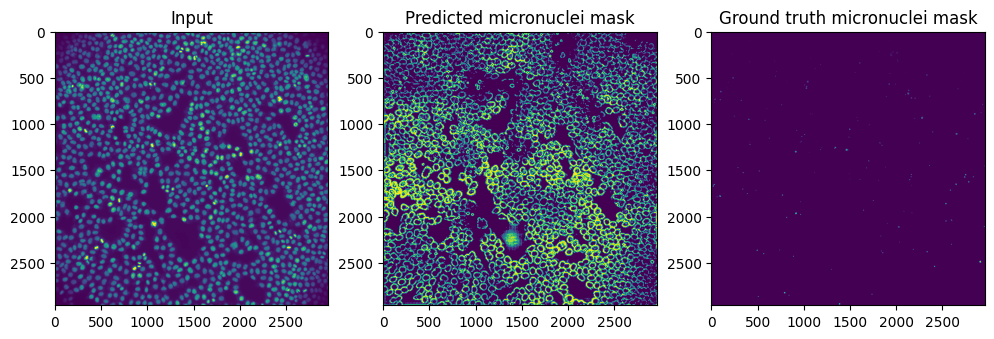

In [36]:
fig, ax = plt.subplots(1,3,figsize=(12,12))

print(imid)
ax[0].imshow(im)
ax[0].set_title('Input')

mn_pred = probabilities[0,:,:] > 0.5
ax[1].imshow(mn_pred)
ax[1].set_title('Predicted micronuclei mask')

ax[2].imshow(mn_gt)
ax[2].set_title('Ground truth micronuclei mask')

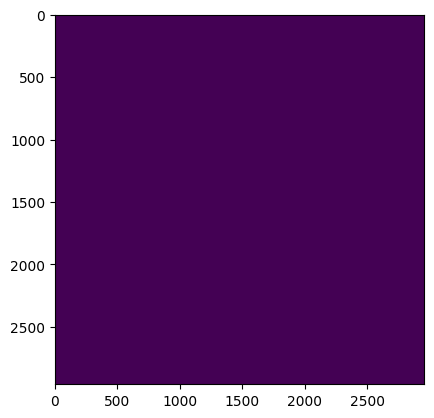

In [37]:
plt.imshow(probabilities[1,:,:] > 5)

- Loading version 2.1

In [39]:
PATCH_SIZE = 256
OUTPUT_DIR = "/model_output/output/"
models_dir = OUTPUT_DIR

model = MicronucleiModel(
    '/scr/yren/micronuclei-detection/microdet/scale_aligned_v2_v3',
    'cuda:3', 
    patch_size=PATCH_SIZE, 
    edges=True, 
    gaussian=False # not needed in predict() function
)

# model.load('best_model_v3.pth', model_dir=models_dir)
model.load('best_model_v2_1.pth', model_dir=models_dir)


Using cache found in /home/MORGRIDGE/yren/.cache/torch/hub/facebookresearch_dinov2_main
/tmp/ipykernel_1142512/188689726.py:248: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


In [40]:
DIRECTORY = '/scr/yren/micronuclei-detection/microdet/scale_aligned_v2_v3'
imid = 'C1-20X_c0_B3_Tile-24'
im = mnds.read_image(DIRECTORY, imid, 'phenotype.tif', scale=1)
im = np.array((im - np.min(im))/(np.max(im) - np.min(im)), dtype="float32")
mn_gt = mnds.read_image(DIRECTORY, imid, 'phenotype_outlines.png', scale=1)
# mn_gt = mn_gt > 0 # convert to boolean (binary mask)

In [ ]:
probabilities = model.predict(im, stride=1, step=16, batch_size=32, dilation=2) # default step 16

100%|██████████| 43/43 [00:16<00:00,  2.55it/s]
/tmp/ipykernel_1142512/188689726.py:311: RuntimeWarning: invalid value encountered in divide
  probabilities = probabilities/counts


In [19]:
print(np.min(im), np.max(im))

0.0 1.0


C1-20X_c0_B3_Tile-24


Text(0.5, 1.0, 'Ground truth micronuclei mask')

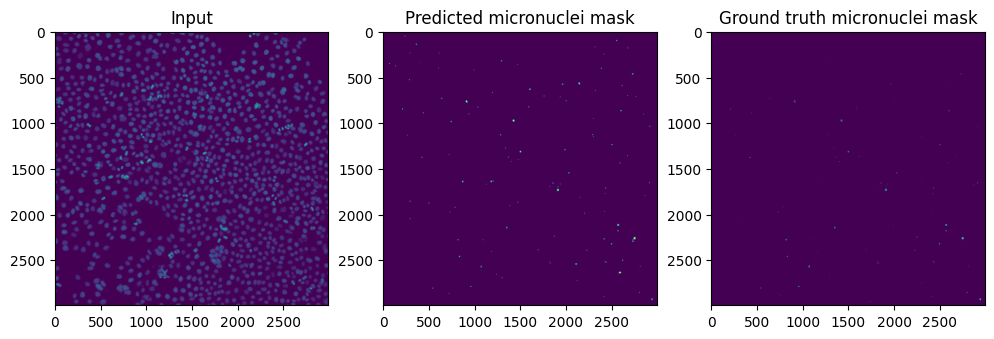

In [46]:
fig, ax = plt.subplots(1,3,figsize=(12,12))

print(imid)
ax[0].imshow(im)
ax[0].set_title('Input')

mn_pred = probabilities[0,:,:] > 0.5
ax[1].imshow(mn_pred)
ax[1].set_title('Predicted micronuclei mask')

ax[2].imshow(mn_gt)
ax[2].set_title('Ground truth micronuclei mask')

In [43]:
import microdet.evaluation

In [47]:
microdet.evaluation.segmentation_report(imid=imid, predictions=mn_pred, gt=mn_gt, intersection_ratio=0.1, report_obj='Micronuclei')

C1-20X_c0_B3_Tile-24,0.7094,0.5929


Error: You must call wandb.init() before wandb.log()

# Jan 14: Check all input and number of data to train & eval

In [1]:
import skimage
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

In [2]:
metadata = pd.read_csv('/scr/yren/all_data_micronuclei/metadata.csv')
print(metadata.shape)

(200, 5)


In [3]:
metadata[metadata.split=='test'].shape

(57, 5)

In [3]:
metadata.head()

,filenames,datasets,magnification,micron,split
0,C1-20X_c0_B3_Tile-5.phenotype.tif,HeLa,20,6.5,train
1,C1-20X_c0_B3_Tile-24.phenotype.tif,HeLa,20,6.5,validation
2,C1-20X_c0_B3_Tile-15.phenotype.tif,HeLa,20,6.5,test
3,C1-20X_c0_phalloidin_C3_Tile-18.phenotype.tif,RPE1,20,6.5,train
4,C1-20X_c0_phalloidin_C3_Tile-15.phenotype.tif,RPE1,20,6.5,validation


In [3]:
metadata[metadata.split == 'validation']

,filenames,datasets,magnification,micron,split
1,C1-20X_c0_B3_Tile-24.phenotype.tif,HeLa,20,6.50,validation
4,C1-20X_c0_phalloidin_C3_Tile-15.phenotype.tif,RPE1,20,6.50,validation
18,20X_c0-DAPI_A1_Tile-50.phenotype.tif,pilot,14,4.25,validation
19,C2-20X_c0-DAPI-GFP_B3_Tile-16.phenotype.tif,screen,14,4.25,validation
20,C2-20X_c0-DAPI-GFP_A2_Tile-5.phenotype.tif,screen,14,4.25,validation
70,2022-05-26_RPE1-2198.phenotype.tif,mnfinder_validation,20,11.00,validation
71,2022-10-14_U2OS-1.phenotype.tif,mnfinder_validation,20,11.00,validation
72,2023-05-31_misc-4.phenotype.tif,mnfinder_validation,20,11.00,validation
74,IXMtest_N12_s7_w166EF3FAB-EA33-4B28-91E3-034A1...,BBBC039,20,13.10,validation
76,IXMtest_I16_s9_w1582FD22A-5270-4FDC-868F-5F758...,BBBC039,20,13.10,validation


In [4]:
metadata[metadata.split == 'train'].shape

(103, 5)

# Get all scaled v2 + v3 data

In [22]:
sub = metadata[metadata.datasets.isin(['HeLa', 'RPE1', 'pilot', 'screen'])]
print(sub.shape)
sub

(24, 5)


,filenames,datasets,magnification,micron,split
0,C1-20X_c0_B3_Tile-5.phenotype.tif,HeLa,20,6.50,train
1,C1-20X_c0_B3_Tile-24.phenotype.tif,HeLa,20,6.50,validation
2,C1-20X_c0_B3_Tile-15.phenotype.tif,HeLa,20,6.50,test
3,C1-20X_c0_phalloidin_C3_Tile-18.phenotype.tif,RPE1,20,6.50,train
4,C1-20X_c0_phalloidin_C3_Tile-15.phenotype.tif,RPE1,20,6.50,validation
5,C1-20X_c0_phalloidin_C3_Tile-44.phenotype.tif,RPE1,20,6.50,test
6,C2-20X_c0-DAPI-GFP_A3_Tile-6.phenotype.tif,screen,14,4.25,train
7,C2-20X_c0-DAPI-GFP_A1_Tile-17.phenotype.tif,screen,14,4.25,train
8,20X_c0-DAPI_A1_Tile-170.phenotype.tif,pilot,14,4.25,train
9,20X_c0-DAPI_A1_Tile-70.phenotype.tif,pilot,14,4.25,train


In [ ]:
im = skimage.io.imread('/scr/yren/all_data_micronuclei/test/C1-20X_c0_phalloidin_C3_Tile-44.phenotype.tif')
print(im.shape)
print(np.min(im), np.max(im))

(2992, 2992)


In [26]:
im = skimage.io.imread('/scr/yren/all_data_micronuclei/test/C1-20X_c0_phalloidin_C3_Tile-44.phenotype_outlines.png')
print(im.shape)
print(np.min(im), np.max(im))

(2992, 2992)
0 60


In [29]:
x = 10.0
print(type(x))

<class 'float'>


In [34]:
import torch

x = torch.tensor([3.14, 2.71])
print(x.long())  # Output: tensor([3, 2])

tensor([3, 2])


In [37]:
(torch.tensor([True, False, True])).float()

tensor([1., 0., 1.])

In [5]:
CURRENT_PATH = '/scr/yren/micronuclei-detection/microdet'
validation_files = os.listdir(CURRENT_PATH + '/all_data_micronuclei/validation')
validation_files = [file for file in validation_files if not file.startswith('.')]
validation_files = [x for x in validation_files if x.endswith('.phenotype_outlines.png')]
validation_files.sort()

validation_filelist = validation_files.copy()
validation_filelist
print(len(validation_filelist))

40


In [6]:
import sys
import os
sys.path.append('../')

import skimage
import numpy as np
import matplotlib.pyplot as plt

In [8]:
path = '/scr/yren/all_data_predictions/'
files = os.listdir(path)
files


['2022-05-26_RPE1-2198._probabilities.npy',
 '2022-10-14_U2OS-1._probabilities.npy',
 '2023-05-31_misc-4._probabilities.npy',
 '20X_c0-DAPI_A1_Tile-50._probabilities.npy',
 'C1-20X_c0_B3_Tile-24._probabilities.npy',
 'C1-20X_c0_phalloidin_C3_Tile-15._probabilities.npy',
 'C2-20X_c0-DAPI-GFP_A2_Tile-5._probabilities.npy',
 'C2-20X_c0-DAPI-GFP_B3_Tile-16._probabilities.npy',
 'IXMtest_B04_s4_w1F6AEFA0F-AF87-4B3B-A334-698647CFE043._probabilities.npy',
 'IXMtest_B12_s2_w19F7E0279-D087-4B5E-9899-61971C29CB78._probabilities.npy',
 'IXMtest_B19_s7_w1E43B84DB-39E2-4BFB-8CB4-554B32098C75._probabilities.npy',
 'IXMtest_C18_s1_w11C16FC59-2E29-496A-803A-89581FDF538A._probabilities.npy',
 'IXMtest_D02_s8_w1AC6783DF-ED35-4818-8091-E6D02AF4BFBD._probabilities.npy',
 'IXMtest_D07_s4_w16CF58D03-0B05-41FE-AE73-7298887DEBB1._probabilities.npy',
 'IXMtest_D19_s6_w1EB1F11AE-4FB6-481F-94D9-40246870F0CB._probabilities.npy',
 'IXMtest_E06_s3_w1701573EB-CE9A-4D76-8668-0416996E1DCD._probabilities.npy',
 'IXMtes

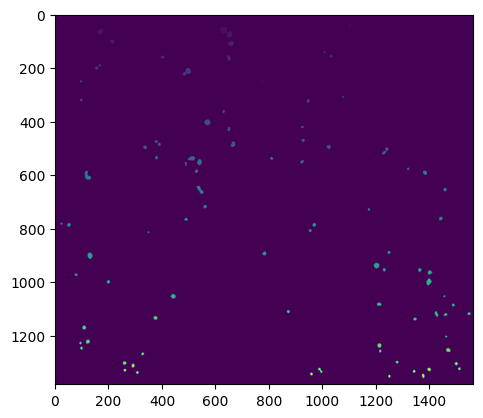

In [9]:
prob = np.load(path + files[0])
plt.imshow(prob)

# Plot overlaps

In [1]:
import numpy as np
import pandas as pd
import skimage
import matplotlib.pyplot as plt
import os

In [19]:
parent_path = '/scr/yren/'
path_pred = parent_path + 'all_data_predictions/IXMtest_P15_s3_w10F5E9699-743C-4177-93CE-27CFD65A925E._probabilities.npy'
path_gt = parent_path + 'all_data_micronuclei/validation/IXMtest_P15_s3_w10F5E9699-743C-4177-93CE-27CFD65A925E.phenotype_outlines.png'
path_nuclei = parent_path + 'all_data_micronuclei/validation/IXMtest_P15_s3_w10F5E9699-743C-4177-93CE-27CFD65A925E.nuclei-clean.tif'
pred = np.load(path_pred)
gt = skimage.io.imread(path_gt)
nuclei = skimage.io.imread(path_nuclei)

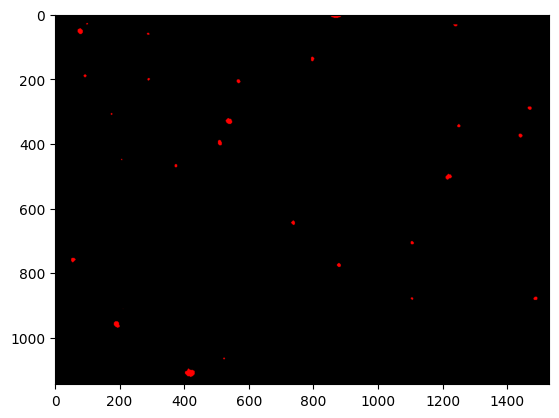

In [15]:
pred = pred > 0
view = np.concatenate([255*pred[:,:,None], np.zeros_like(pred)[:,:,None], np.zeros_like(pred)[:,:,None]], axis=2)
plt.imshow(view, cmap='gray')

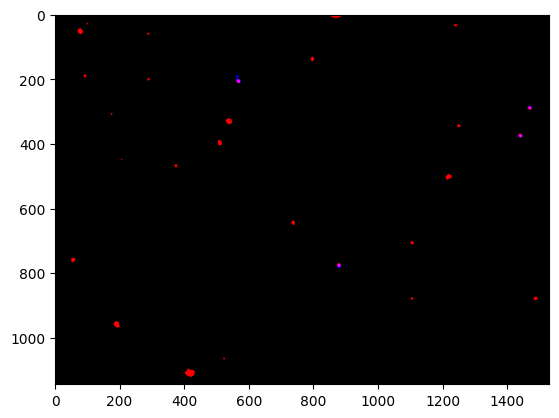

In [16]:
gt = gt > 0
view2 = np.concatenate([255*pred[:,:,None], np.zeros_like(pred)[:,:,None], 255*gt[:,:,None]], axis=2)
plt.imshow(view2, cmap='gray')

Text(0.5, 1.0, 'Overlaps')

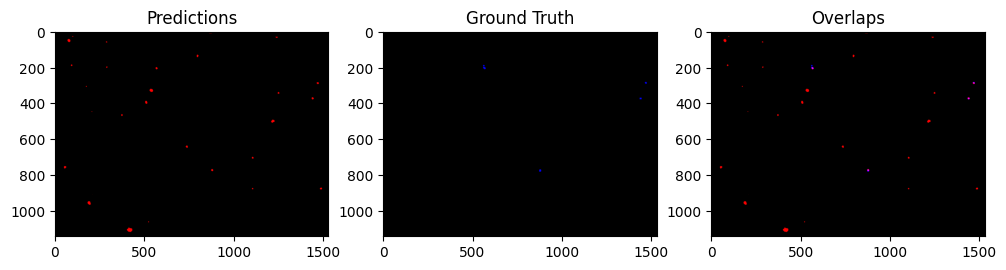

In [17]:
fig, ax = plt.subplots(1,3,figsize=(12,12))

ax[0].imshow(view)
ax[0].set_title('Predictions')

gt_view = np.concatenate([np.zeros_like(gt)[:,:,None], np.zeros_like(gt)[:,:,None], 255*gt[:,:,None]], axis=2)
ax[1].imshow(gt_view)
ax[1].set_title('Ground Truth')

ax[2].imshow(view2)
ax[2].set_title('Overlaps')

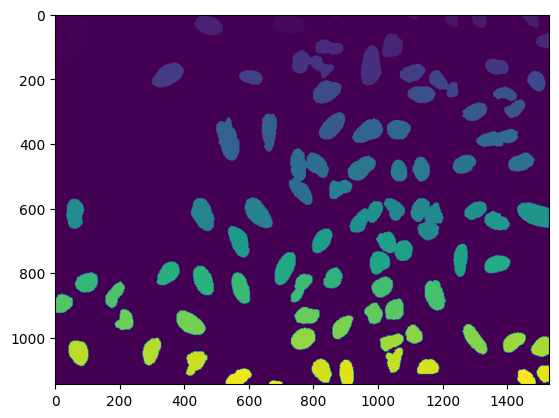

In [20]:
plt.imshow(nuclei)

In [9]:
path = '/scr/yren/LOO_HeLa_RPE/'
files = os.listdir(path)
files = [file for file in files if not file.startswith('.')]
files = [file for file in files if file.endswith('phenotype_outlines.png')]
print(len(files))

200


In [21]:
hela_rpe_ids = ['C1-20X_c0_B3_Tile-15.phenotype_outlines.png', 
                'C1-20X_c0_B3_Tile-24.phenotype_outlines.png', 
                'C1-20X_c0_B3_Tile-5.phenotype_outlines.png', 
                'C1-20X_c0_phalloidin_C3_Tile-15.phenotype_outlines.png', 
                'C1-20X_c0_phalloidin_C3_Tile-18.phenotype_outlines.png', 
                'C1-20X_c0_phalloidin_C3_Tile-44.phenotype_outlines.png']
i = 0
hela_rpe_ids[i]

'C1-20X_c0_B3_Tile-15.phenotype_outlines.png'

In [27]:
for i in range(len(hela_rpe_ids)):
    print(files.index(hela_rpe_ids[i]))

59
60
61
62
63
64


In [23]:
training_files = files.copy()
del training_files[59]

# Make prediction on HeLa & RPE using model v2.1, plot overlaps and save as npy

In [28]:
df = pd.read_csv('/scr/yren/all_data_micronuclei/metadata.csv')
hela_rpe = df[df.datasets.isin(['HeLa', 'RPE1'])]
hela_rpe

,filenames,datasets,magnification,micron,split
0,C1-20X_c0_B3_Tile-5.phenotype.tif,HeLa,20,6.5,train
1,C1-20X_c0_B3_Tile-24.phenotype.tif,HeLa,20,6.5,validation
2,C1-20X_c0_B3_Tile-15.phenotype.tif,HeLa,20,6.5,test
3,C1-20X_c0_phalloidin_C3_Tile-18.phenotype.tif,RPE1,20,6.5,train
4,C1-20X_c0_phalloidin_C3_Tile-15.phenotype.tif,RPE1,20,6.5,validation
5,C1-20X_c0_phalloidin_C3_Tile-44.phenotype.tif,RPE1,20,6.5,test


# Plot overlaps for model3 validation predictions (save as npy)

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skimage

In [22]:
path = '/scr/yren/all_data_predictions/'
save_path = '/scr/yren/modelv3_val_overlap/'

predictions = os.listdir(path)

for i in range(len(predictions)):
    # load predictions
    pred = np.load(path + predictions[i])
    pred = pred > 0
    
    # load ground truth
    imid = predictions[i].split('.')[0]
    gt = skimage.io.imread(f'/scr/yren/all_data_micronuclei/validation/{imid}.phenotype_outlines.png')
    gt = gt > 0
    
    overlap = np.concatenate([255*pred[:,:,None], np.zeros_like(pred)[:,:,None], 255*gt[:,:,None]], axis=2)
    
    filename = predictions[i].replace('_probabilities', '_overlap')
    np.save(save_path + filename, overlap)

In [26]:
import time

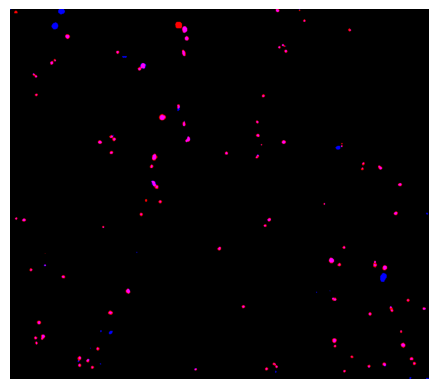

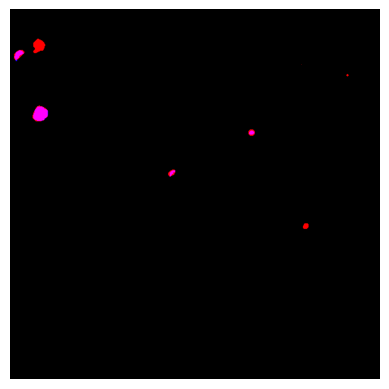

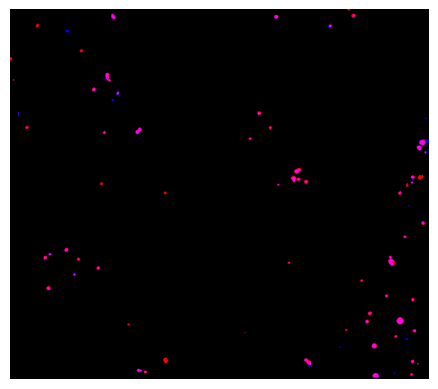

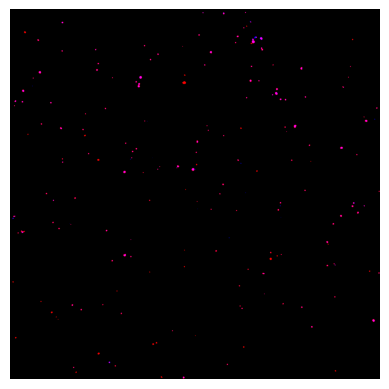

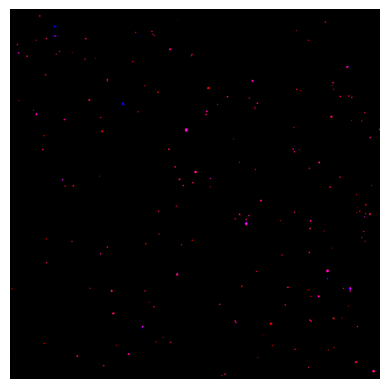

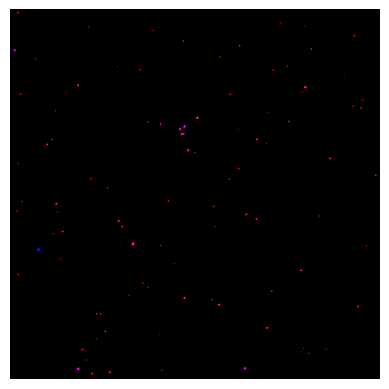

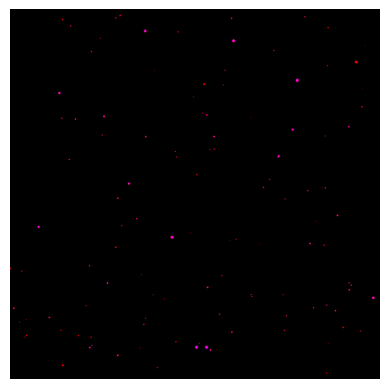

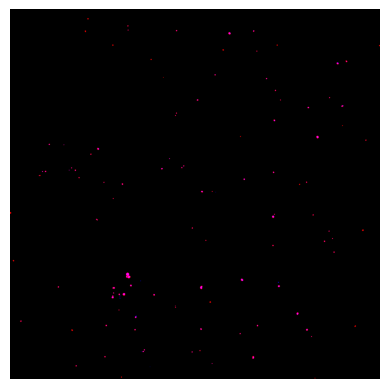

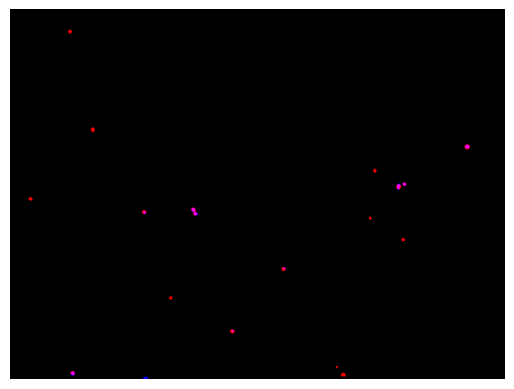

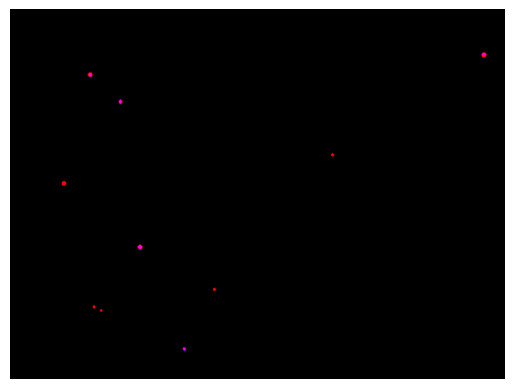

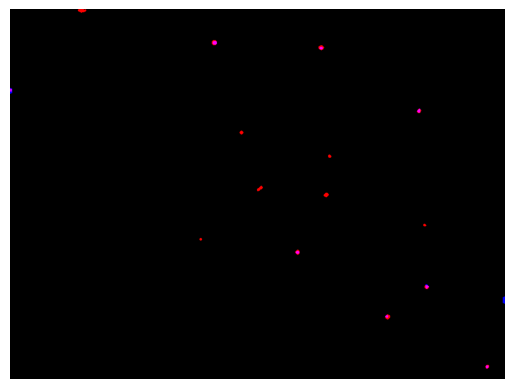

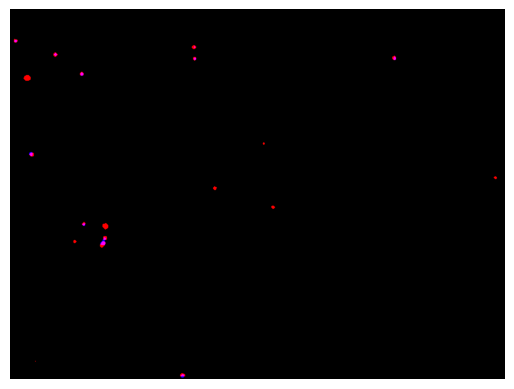

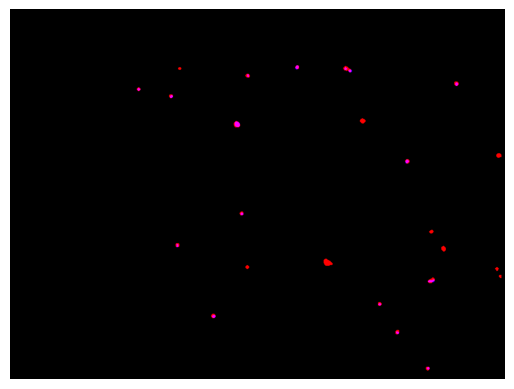

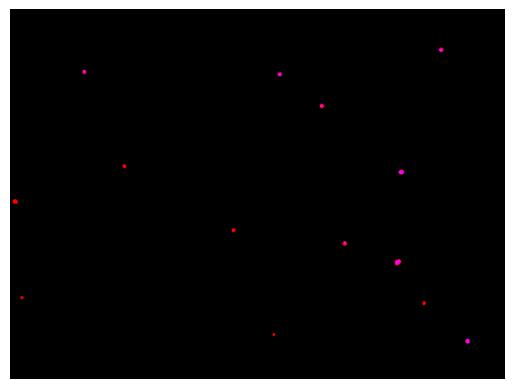

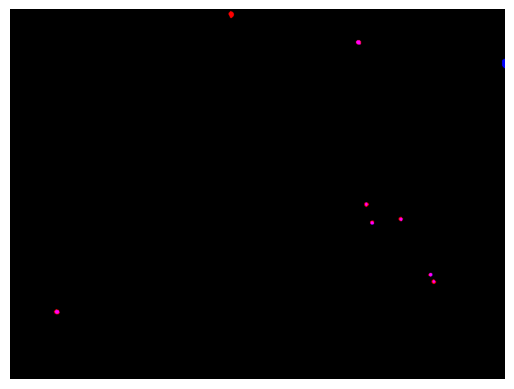

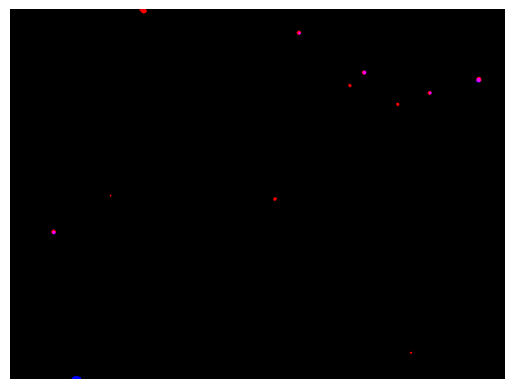

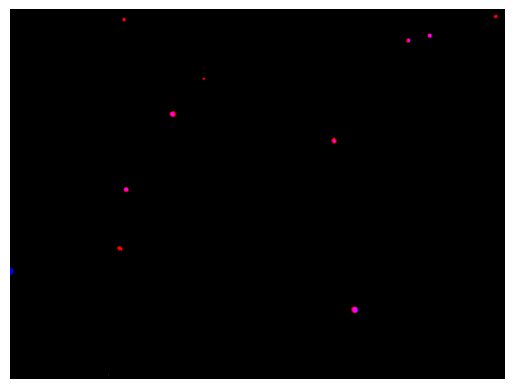

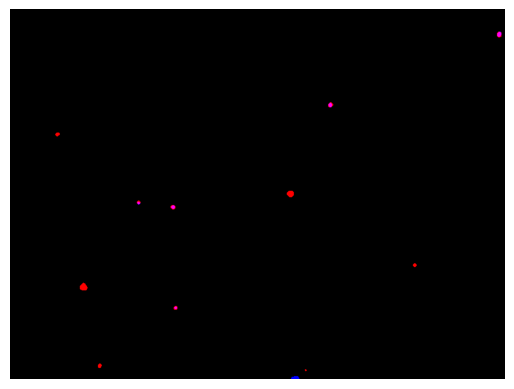

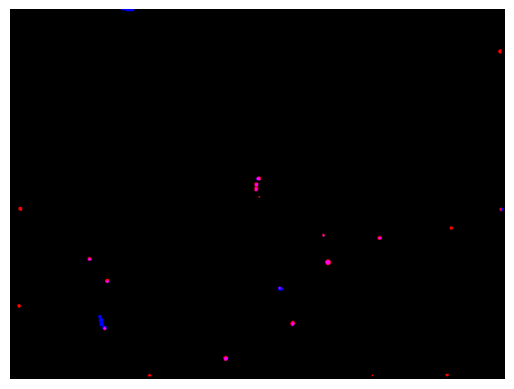

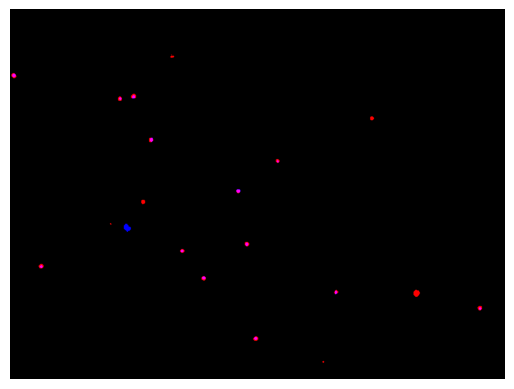

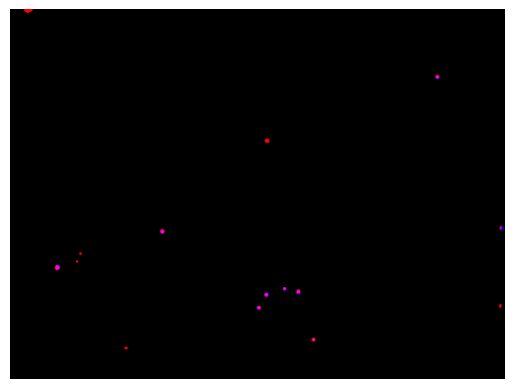

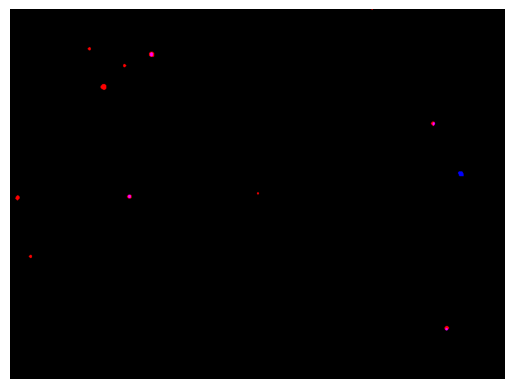

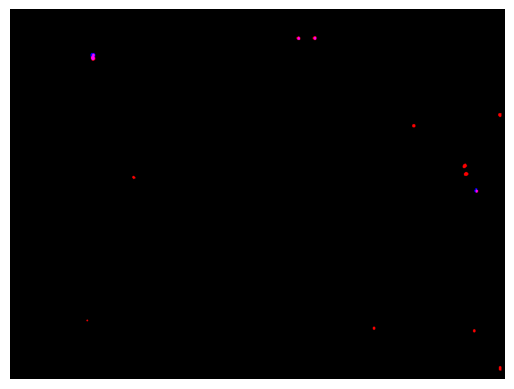

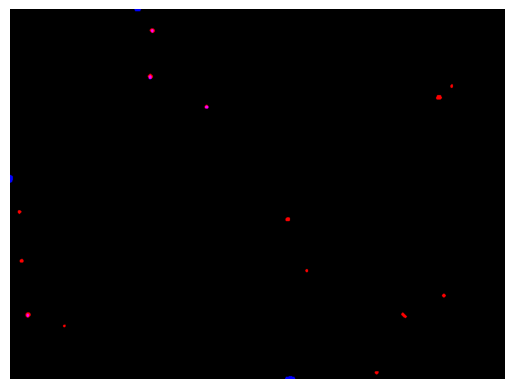

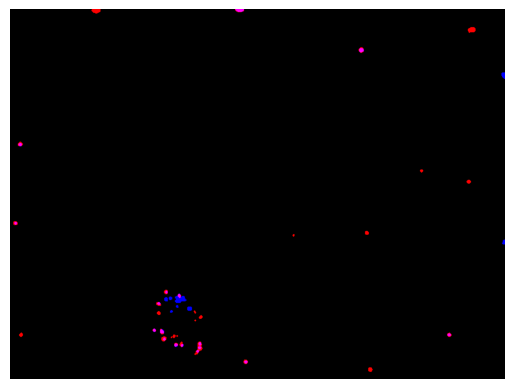

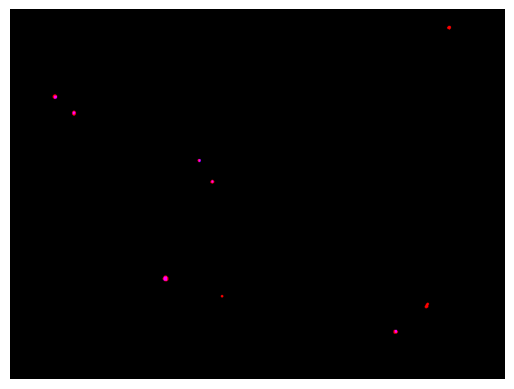

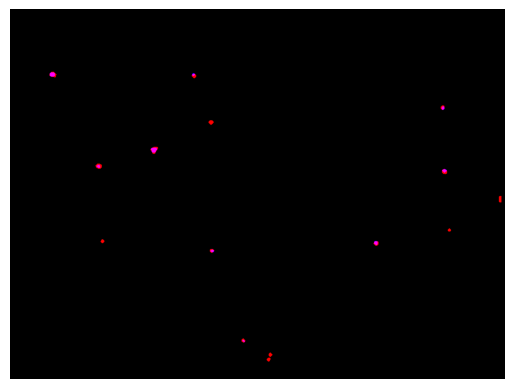

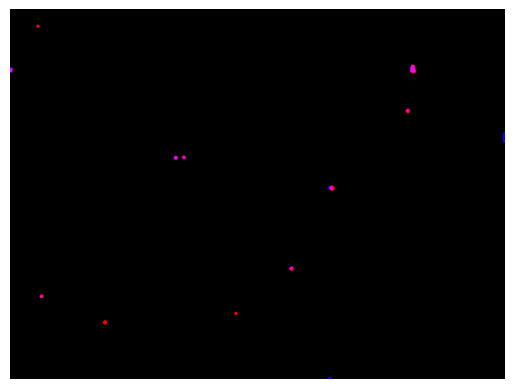

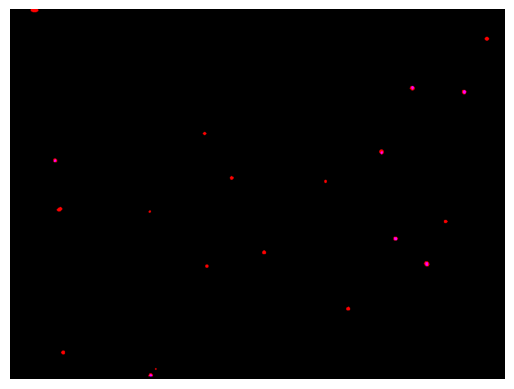

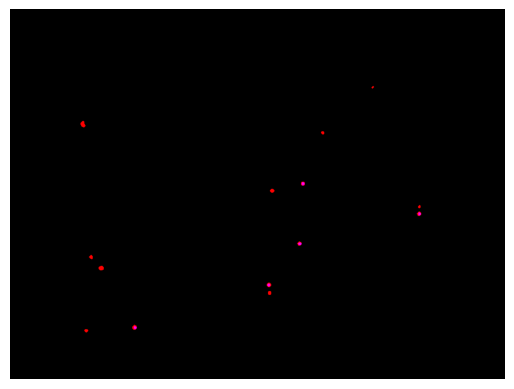

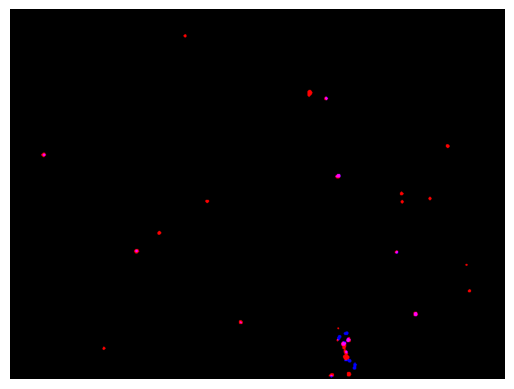

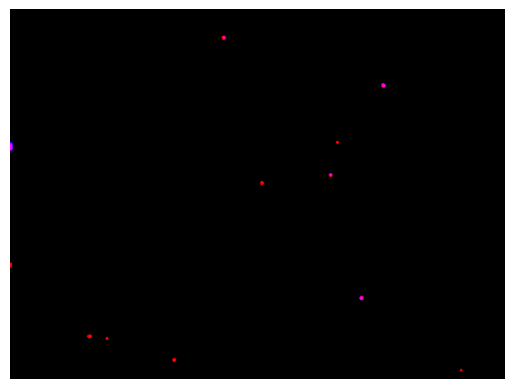

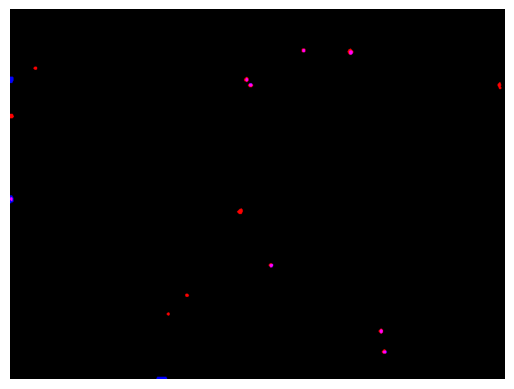

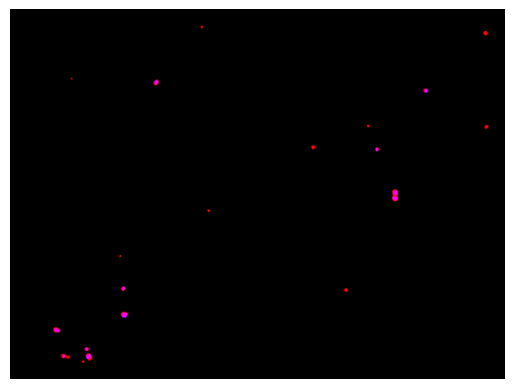

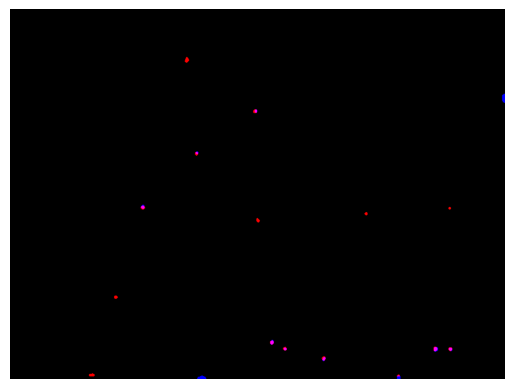

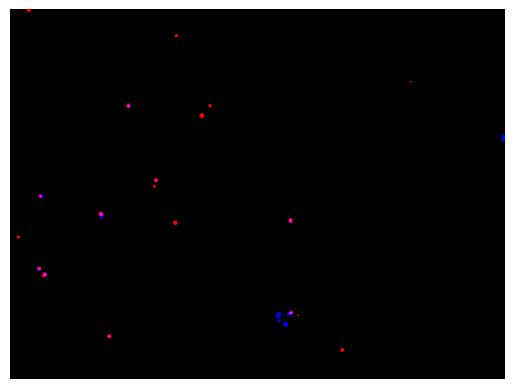

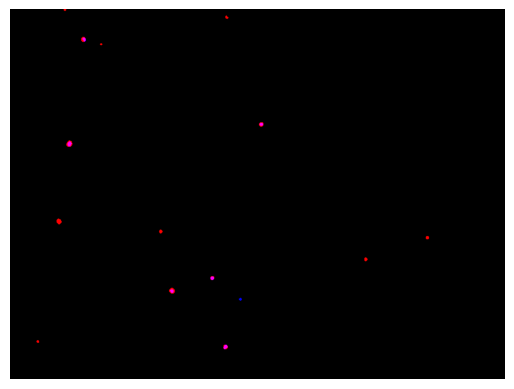

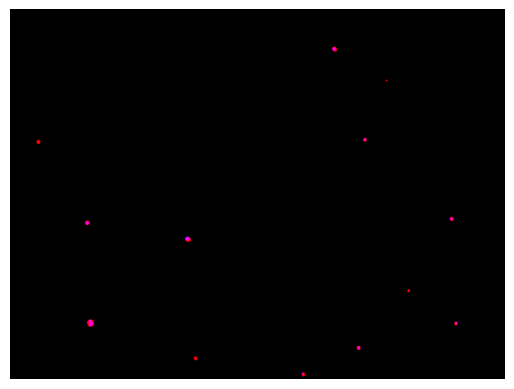

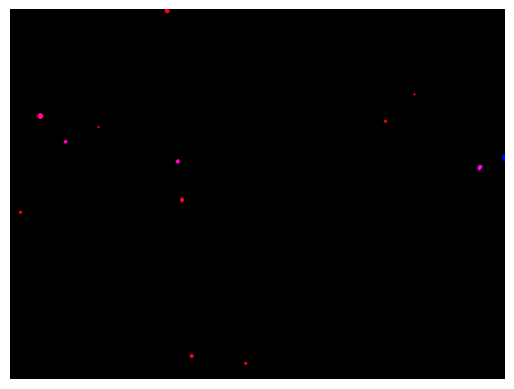

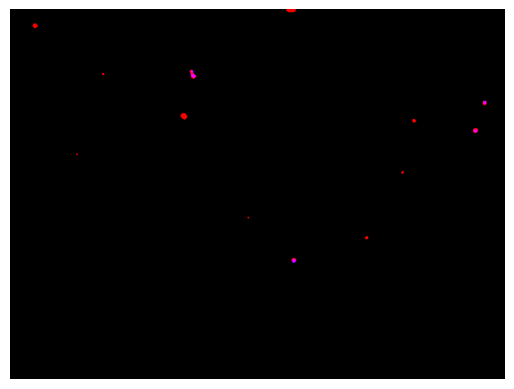

In [ ]:
overlaps = os.listdir(save_path)
for i in overlaps:
    overlap = np.load(save_path + i)
    
    plt.imshow(overlap)
    plt.axis('off')
    plt.show()
    plt.close('all')
    # time.sleep(1)

In [22]:
import pandas as pd

In [24]:
metadata = pd.read_csv('/scr/yren/all_data_micronuclei/metadata.csv')
metadata.shape

(232, 5)

In [25]:
import numpy as np

In [26]:
np.unique(metadata.datasets.tolist())

array(['BBBC039', 'HeLa', 'RPE1', 'mnfinder_test', 'mnfinder_train',
       'mnfinder_validation', 'pilot', 'screen'], dtype='<U19')

In [27]:
mnfinder = metadata[metadata.datasets.isin(['mnfinder_test', 'mnfinder_train', 'mnfinder_validation'])]

In [28]:
mnfinder[mnfinder.magnification==40].filenames.iloc[0]

'2023-05-31_misc-3.phenotype.tif'

In [29]:
mnfinder[mnfinder.magnification==40]

,filenames,datasets,magnification,micron,split
36,2023-05-31_misc-3.phenotype.tif,mnfinder_train,40,11.0,train
37,2023-05-31_misc-2.phenotype.tif,mnfinder_train,40,11.0,train
38,2023-05-31_misc-1.phenotype.tif,mnfinder_train,40,11.0,train
54,2023-05-31_misc-MAX_2021_3_11_heladcas9_1_chr1...,mnfinder_test,40,13.0,test
59,2023-05-31_misc-MAX_2021_3_25_hela_misseg_dcas...,mnfinder_test,40,13.0,test
64,2023-05-31_misc-MAX_2021_3_25_hela_misseg_dcas...,mnfinder_test,40,13.0,test
72,2023-05-31_misc-4.phenotype.tif,mnfinder_validation,40,11.0,validation
